# Des Moines, IA — Land Value Tax Shift Modeling

Models a revenue-neutral shift toward land value taxation for parcels inside
the City of Des Moines corporate limits, using FY 2025-26 (AY 2024) Iowa
rates and Polk County's published consolidated tax-levy table.

## Policy assumptions

Recorded per the [LVT Modeling Guide](../LVT_MODELING_GUIDE.md) §Q1.0:

| Choice | Setting | Note |
|---|---|---|
| Policy scope | **Full levy stack** | City + county + school + community college + assessor + ag-extension + state. Models the cumulative effect across all overlapping levies, not just the city's slice. |
| Reform shape | **Split-rate at multiple ratios + full building abatement** | Scenarios at 2:1, 4:1, 8:1 (land:improvement), plus a 100%-building-exemption scenario for comparison. |
| Rates source | **Iowa DoM rollback + Polk consolidated levies** | Published rates joined per-parcel via the district sidecar. See "Sources" cell. |
| District granularity | **Multi-overlay** (school × SSMID × urban sanitary) | Each parcel's consolidated millage reflects its actual combination of overlapping taxing authorities. |
| TIF treatment | **Dual reporting** | All scenarios run twice — once including TIF-captured parcels, once excluding. |
| Current structure preserved? | **Yes** | Existing exemptions, class rates, rollback, and post-tax credits remain. The only thing the reform changes is the land-vs-improvement split of the rate structure. |
| Intentional departures from current law | None | This is a rate-structure shift, not a full property-tax redesign. |
| **Ag carve-out** | **Yes (default throughout)** | Agricultural parcels are exempt from the LVT solve in every scenario. They keep their current productivity-based property tax. They still benefit from income-tax abolition (Schedule F filers save) and receive the citizens dividend (per-capita), but never pay extra property tax to fund either. See §5 for the mechanic. |

## Sources

- **Iowa Department of Revenue rollback (FY26 / AY2024)** — Iowa Legislative Services Agency
  [Assessment Limitations — Property Value Rollbacks](https://www.legis.iowa.gov/docs/publications/FTNO/1543666.pdf)
  (Residential 47.4316%; Commercial/Industrial two-tier: residential rate on first $150,000, 90% above)
- **Polk County FY26 Consolidated Tax Levy Rates** — Polk County Auditor
  [tax-rate-and-valuation-information](https://www.polkcountyiowa.gov/county-auditor/property-tax/tax-rate-and-valuation-information/)
  (PDF: 2024 Assessed Valuations - Taxes Payable Sep 2025 and March 2026)
- **Polk County district + TIF boundaries** — Polk County Auditor ArcGIS, Auditor_Export FeatureServer

## Inputs

- `cities/des_moines/data/des_moines_mapping_ready_<date>.parquet` — produced by `data/jurisidictions/run_des_moines.py` (geovizwiz-sb side) and deposited into LVTShift; PROFILE_MODELING schema.
- `cities/des_moines/data/des_moines_districts_<date>.parquet` — produced by `scripts/des_moines_district_overlay.py`. Per-parcel: school district, SSMID, urban-sanitary, TIF flag/name, Iowa DoM 6-digit tax-district code, FY26 consolidated millage.

If the second file is missing, run:
```
python scripts/des_moines_district_overlay.py
```


In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

# Notebook lives at cities/des_moines/model.ipynb; repo root is two up.
sys.path.insert(0, str(Path('../..').resolve()))
REPO_ROOT = Path('../..').resolve()

# Load CENSUS_API_KEY (and anything else) from the repo-root .env.
load_dotenv(REPO_ROOT / ".env")

from lvt import lvt_utils, census_utils, policy_analysis, viz, lodes_utils


## 1. Rate constants (FY26 / AY 2024)

Hardcoded annually from the published sources cited above. When Iowa DoR
publishes the AY 2025 rollback (around November 2025) or Polk publishes the
FY 2026-27 consolidated rate table (around July 2026), update these values
**and** rerun `scripts/des_moines_district_overlay.py` so the sidecar reflects
the new district rates.

In [2]:
# Iowa rollback (Assessment Limitation) — Assessment Year 2024 / Fiscal Year 2026.
# Residential and "multi-residential" (combined into residential class since AY2022).
ROLLBACK_RESIDENTIAL = 0.474316  # = 47.4316%
# Commercial / Industrial / Railroad two-tier (per 2022 Iowa Acts ch 1061):
#   first $150,000 of value uses the residential rate, remainder uses 90%.
COMM_TIER1_THRESHOLD = 150_000
COMM_TIER1_RATE = ROLLBACK_RESIDENTIAL
COMM_TIER2_RATE = 0.90
# Agricultural rollback is productivity-based and county-specific; published
# annually. The 2024 Iowa DoR Assessment Limitation Order set it at
# approximately 0.8907 for AY 2024. Update from Iowa DoR if precise values
# are needed; ag is a tiny share of DM parcels.
ROLLBACK_AGRICULTURAL = 0.8907  # TODO: verify against Iowa DoR AY2024 limitation order
# Utility / railroad assessed at 100% (not rollback-eligible above $150K threshold for railroad).
ROLLBACK_UTILITY = 1.0


### Class → rollback bucket

The Polk Assessor `Class` codes are mapped to rollback buckets. Multi-residential
was folded into residential by 2021 Iowa Acts ch 20, so apartments / nursing
homes / mobile-home parks get the residential rate. "Exempt"-suffixed classes
are dropped from the revenue-neutral solve below.

In [3]:
# Map Polk's property_land_use_category strings to rollback buckets.
RESIDENTIAL_CLASSES = {"Residential", "Res 3+", "Comm, Res3+"}
COMMERCIAL_CLASSES  = {"Comm", "Industrial"}
AGRICULTURAL_CLASSES = {"Agricultural", "Ag, Ag Res"}
UTILITY_CLASSES     = {"Utility"}
EXEMPT_CLASSES      = {
    "Govt", "School",
    "Comm Exempt", "Res Exempt", "Res 3+ Exempt",
    "Comm, Comm Ex", "Res3+, Comm Ex", "Com,Res3+,Comex", "Res, Res Ex",
}
# Anything not in the above buckets defaults to residential (covers "Other",
# "Condo Header", and trace mixed-use codes).

def rollback_bucket(cls: object) -> str:
    cls = str(cls or "").strip()
    if cls in EXEMPT_CLASSES:       return "exempt"
    if cls in COMMERCIAL_CLASSES:   return "commercial"
    if cls in AGRICULTURAL_CLASSES: return "agricultural"
    if cls in UTILITY_CLASSES:      return "utility"
    return "residential"


## 2. Load parcels + district sidecar

In [4]:
data_dir = Path("data")

parcel_files = sorted(data_dir.glob("des_moines_mapping_ready_*.parquet"))
sidecar_files = sorted(data_dir.glob("des_moines_districts_*.parquet"))
if not parcel_files:
    raise FileNotFoundError(f"No des_moines_mapping_ready_*.parquet under {data_dir}")
if not sidecar_files:
    raise FileNotFoundError(
        f"No des_moines_districts_*.parquet under {data_dir}. "
        "Run: python scripts/des_moines_district_overlay.py"
    )

gdf = gpd.read_parquet(parcel_files[-1])
sidecar = pd.read_parquet(sidecar_files[-1])
gdf = gdf.merge(sidecar, on="parcel_id", how="left")

print(f"Parcels:  {parcel_files[-1].name}  ({len(gdf):,} rows)")
print(f"Districts: {sidecar_files[-1].name}  ({len(sidecar):,} rows)")
unmatched = gdf["tax_district_name"].isna().sum()
if unmatched:
    print(f"⚠ {unmatched:,} parcels missing a tax district (will default to base DM SCH rate)")


Parcels:  des_moines_mapping_ready_2026_05_22.parquet  (47,634 rows)
Districts: des_moines_districts_2026_05_23.parquet  (47,634 rows)


In [5]:
gdf[[
    "parcel_id", "property_land_use_category", "PROPERTY_CATEGORY",
    "land_value", "improvement_value", "full_market_value",
    "school_district_pdf", "ssmid_pdf", "in_tif", "tif_district",
    "tax_district_name", "consolidated_millage",
]].head()


,parcel_id,property_land_use_category,PROPERTY_CATEGORY,land_value,improvement_value,full_market_value,school_district_pdf,ssmid_pdf,in_tif,tif_district,tax_district_name,consolidated_millage
0,782305101002,Govt,None,0,0,0,DM SCH,None,0,None,DES MOINES CITY/DM SCH,42.32446
1,782305101003,Govt,None,0,0,0,DM SCH,None,0,None,DES MOINES CITY/DM SCH,42.32446
2,782305101004,Res 3+,None,47500,667500,715000,DM SCH,None,0,None,DES MOINES CITY/DM SCH,42.32446
3,782305101012,Residential,None,45600,150300,195900,DM SCH,None,0,None,DES MOINES CITY/DM SCH,42.32446
4,782305101013,Res 3+,None,84600,549400,634000,DM SCH,None,0,None,DES MOINES CITY/DM SCH,42.32446


## 3. Apply class rollback → taxable value

Iowa's order of operations: assessed value × class-specific rollback = taxable value.
Commercial/industrial use a two-tier rollback. Exempt-classed parcels are flagged
so they're excluded from the revenue-neutral solve below.

In [6]:
gdf["rollback_bucket"] = gdf["property_land_use_category"].apply(rollback_bucket)

# Override the exemption_flag — Polk's CSV ships exempt-classed parcels with flag=0,
# but for modeling we want to exclude any class-tagged exempt from the solve.
gdf["exemption_flag"] = (gdf["rollback_bucket"] == "exempt").astype(int)

def _taxable_value(row: pd.Series) -> float:
    fmv = float(pd.to_numeric(row["full_market_value"], errors="coerce") or 0.0)
    if fmv <= 0:
        return 0.0
    bucket = row["rollback_bucket"]
    if bucket == "exempt":
        return 0.0
    if bucket == "residential":
        return fmv * ROLLBACK_RESIDENTIAL
    if bucket == "commercial":
        # Iowa two-tier (lvt_utils.apply_two_tier_rollback): first $150K at
        # residential rate, remainder at 90%.
        return lvt_utils.apply_two_tier_rollback(
            fmv, COMM_TIER1_THRESHOLD, COMM_TIER1_RATE, COMM_TIER2_RATE
        )
    if bucket == "agricultural":
        return fmv * ROLLBACK_AGRICULTURAL
    if bucket == "utility":
        return fmv * ROLLBACK_UTILITY
    return fmv * ROLLBACK_RESIDENTIAL

gdf["taxable_value"] = gdf.apply(_taxable_value, axis=1)
# Re-derive the land vs improvement split on the taxable side, preserving the
# improvement ratio per parcel (so the split-rate solver operates on taxable
# values, consistent with Iowa law).
fmv = pd.to_numeric(gdf["full_market_value"], errors="coerce").replace(0, np.nan)
land_share = pd.to_numeric(gdf["land_value"], errors="coerce") / fmv
imp_share = 1.0 - land_share
gdf["taxable_land_value"] = (gdf["taxable_value"] * land_share).fillna(0.0).clip(lower=0.0)
gdf["taxable_improvement_value"] = (gdf["taxable_value"] * imp_share).fillna(0.0).clip(lower=0.0)

# Build a chart-friendly category via policy_analysis.build_chart_category.
# Vacant / Parking Lot / Underdeveloped parcels get their own rows EXCEPT
# when they're agricultural (undeveloped farmland trips the vacant heuristic
# but is actively in use as ag, not a redevelopment target).
gdf["chart_category"] = policy_analysis.build_chart_category(
    gdf,
    base_col="property_land_use_category",
    refined_col="PROPERTY_CATEGORY",
    exclude_mask=(gdf["rollback_bucket"] == "agricultural"),
)

print("Rollback bucket distribution:")
print(gdf["rollback_bucket"].value_counts(dropna=False).to_string())
print()
print(f"Total assessed value (full market): ${gdf['full_market_value'].sum():>20,.0f}")
print(f"Total taxable value (post-rollback): ${gdf['taxable_value'].sum():>19,.0f}")
print(f"Implied effective rollback:           {gdf['taxable_value'].sum()/max(gdf['full_market_value'].sum(),1):>20.4f}")


Rollback bucket distribution:
rollback_bucket
residential     43413
commercial       2544
exempt           1534
agricultural      110
utility            33

Total assessed value (full market): $      17,122,308,100
Total taxable value (post-rollback): $      8,596,190,743
Implied effective rollback:                         0.5020


## 4. Compute current tax (full levy stack)

`current_tax = taxable_value × consolidated_millage / 1000` per parcel.
Consolidated millage comes from the sidecar — each parcel gets the FY26 rate
matching its school × SSMID × urban-sanitary combination.

In [7]:
total_revenue, _, gdf = lvt_utils.calculate_current_tax(
    gdf,
    tax_value_col="taxable_value",
    millage_rate_col="consolidated_millage",
    exemption_col=None,
    exemption_flag_col="exemption_flag",
    percentage_cap_col=None,
)
print(f"Total current property tax (full stack, taxable):  ${total_revenue:,.0f}")
print(f"Median parcel current_tax:                          ${gdf['current_tax'].median():,.0f}")
print(f"Mean parcel current_tax (non-exempt):               ${gdf.loc[gdf['exemption_flag']==0,'current_tax'].mean():,.0f}")
print()
print("Per-district revenue contribution (top 5):")
by_district = gdf.groupby("tax_district_name")["current_tax"].sum().sort_values(ascending=False).head(5)
print(by_district.apply(lambda v: f"${v:,.0f}").to_string())


Total current property tax (full stack, taxable):  $366,585,112
Median parcel current_tax:                          $3,993
Mean parcel current_tax (non-exempt):               $7,952

Per-district revenue contribution (top 5):
tax_district_name
DES MOINES CITY/DM SCH                          $267,226,111
DES MOINES CITY/DM SCH/DOWNTOWN SSMID            $64,368,821
DES MOINES CITY/SE-POLK SCH                       $9,071,003
DES MOINES CITY/JOHNSTON SCH                      $7,594,807
DES MOINES CITY/DM SCH/INGERSOLL GRAND SSMID      $5,592,389


## 5. Reform scenarios

Four scenarios, each revenue-neutral against the current full-stack tax above:

- **Split-rate 2:1** — land taxed at 2× improvement rate
- **Split-rate 4:1** — land taxed at 4× improvement rate (primary scenario for charts)
- **Split-rate 8:1** — land taxed at 8× improvement rate
- **Full building abatement** — improvements completely exempt; land carries the full revenue

Each runs on `taxable_land_value` / `taxable_improvement_value` (post-rollback),
mirroring the order of operations from Section 3.

**Agricultural parcels are carved out of the LVT solve by default.** Iowa
already taxes ag at productivity (not market) values, and Iowa property tax
policy treats ag as a separate regime. Carving ag out means:

- Ag parcels' property tax stays at the current productivity-based amount
  under every scenario (their `new_tax` = `current_tax`).
- The non-ag revenue target is reduced by ag's current property tax
  contribution (~$400k city-wide), then the solver works on non-ag parcels
  only. The land millage barely moves because ag is so small in DM.
- Ag still benefits from the income tax abolition (farmers file via
  Schedule F) and receives the citizens dividend (per-capita) in later
  sections — but never pays additional property tax to fund those.

To disable the carve-out, pass `exclude_ag=False` to `run_scenarios`.

In [8]:
PRIMARY_RATIO = 4.0  # the scenario downstream charts use

# Categories carved out of the LVT solve (kept unchanged at current_tax).
AG_CARVEOUT_CATEGORIES = {"Agricultural", "Ag, Ag Res"}


def run_scenarios(input_df: pd.DataFrame, target_revenue: float,
                  exclude_ag: bool = True) -> dict:
    """Thin wrapper around lvt_utils.run_revenue_neutral_scenarios that picks the
    DM-specific carve-out mask (chart_category in {"Agricultural", "Ag, Ag Res"})."""
    if exclude_ag and "chart_category" in input_df.columns:
        mask = input_df["chart_category"].isin(AG_CARVEOUT_CATEGORIES)
    else:
        mask = None
    return lvt_utils.run_revenue_neutral_scenarios(
        input_df,
        target_revenue=target_revenue,
        land_value_col="taxable_land_value",
        improvement_value_col="taxable_improvement_value",
        ratios=(2.0, 4.0, 8.0),
        include_full_abatement=True,
        exclude_mask=mask,
        current_tax_col="current_tax",
        exemption_flag_col="exemption_flag",
    )

scenarios_all = run_scenarios(gdf, total_revenue)
print(f"{'Scenario':<35}{'Land mills':>14}{'Imp mills':>14}{'New revenue':>18}{'Drift':>10}")
print("-" * 91)
for key, s in scenarios_all.items():
    drift_pct = abs(s["new_revenue"] - total_revenue) / total_revenue * 100
    print(f"{s['label']:<35}{s['land_millage']:>14.4f}{s['improvement_millage']:>14.4f}{s['new_revenue']:>18,.0f}{drift_pct:>9.4f}%")


Building abatement model (100.0% abatement)
Millage rate: 209.7003
Total tax revenue: $366,184,521.84
Target revenue: $366,184,521.84
Revenue difference: $0.00 (0.0000%)
Scenario                               Land mills     Imp mills       New revenue     Drift
-------------------------------------------------------------------------------------------
Split-rate 2:1                            70.8759       35.4379       366,585,112   0.0000%
Split-rate 4:1                           105.9441       26.4860       366,585,112   0.0000%
Split-rate 8:1                           140.7692       17.5962       366,585,112   0.0000%
Full building abatement (100%)           209.7003        0.0000       366,585,112   0.0000%


## 6. TIF dual analysis

Des Moines has ~3,569 parcels (7.5%) captured by TIF districts. In TIF, the
incremental valuation above a frozen base goes to the TIF, not the general fund.
For a city general-fund analysis, the honest treatment is to exclude TIF-captured
parcels from the revenue-neutral solve.

Below we run the scenarios twice — first on all parcels (including TIF), then
excluding TIF. The two sides give a sense of how much TIF distorts the rate
needed to hit the revenue target.

In [9]:
# Compute the "city general fund" target revenue when TIF is excluded.
# We treat TIF-captured parcels as currently contributing zero to the general
# fund (a conservative simplification — actual TIF mechanics are more granular).
non_tif_mask = gdf["in_tif"] == 0
non_tif_current_revenue = float(gdf.loc[non_tif_mask, "current_tax"].sum())
print(f"Revenue if TIF parcels excluded: ${non_tif_current_revenue:,.0f}")
print(f"Revenue with TIF included:       ${total_revenue:,.0f}")
print(f"TIF share of taxable revenue:    {(total_revenue-non_tif_current_revenue)/total_revenue*100:.1f}%")

scenarios_no_tif = run_scenarios(gdf.loc[non_tif_mask].copy(), non_tif_current_revenue)

print()
print(f"{'Scenario':<35}{'Land mills (incl TIF)':>22}{'Land mills (excl TIF)':>22}{'Diff':>10}")
print("-" * 91)
for key in scenarios_all:
    a = scenarios_all[key]["land_millage"]
    b = scenarios_no_tif[key]["land_millage"]
    print(f"{scenarios_all[key]['label']:<35}{a:>22.4f}{b:>22.4f}{(b-a):>10.4f}")


Revenue if TIF parcels excluded: $240,445,088
Revenue with TIF included:       $366,585,112
TIF share of taxable revenue:    34.4%
Building abatement model (100.0% abatement)
Millage rate: 211.2623
Total tax revenue: $240,057,877.78
Target revenue: $240,057,877.78
Revenue difference: $-0.00 (-0.0000%)

Scenario                            Land mills (incl TIF) Land mills (excl TIF)      Diff
-------------------------------------------------------------------------------------------
Split-rate 2:1                                    70.8759               70.6514   -0.2245
Split-rate 4:1                                   105.9441              105.8904   -0.0537
Split-rate 8:1                                   140.7692              141.0718    0.3026
Full building abatement (100%)                   209.7003              211.2623    1.5620


## 7. Primary scenario for downstream analysis

Use the **4:1 split-rate, including TIF** as the primary scenario for category
summaries, high-impact parcels, land-use diagnostics, and equity charts.
Switch `primary` below to a different scenario key to reset the downstream lens.

In [10]:
primary_key = "split_4_1"
primary = scenarios_all[primary_key]
gdf = primary["df"]  # has current_tax + new_tax columns

gdf["tax_change"] = gdf["new_tax"] - gdf["current_tax"]
gdf["tax_change_pct"] = np.where(
    gdf["current_tax"] > 0,
    100 * gdf["tax_change"] / gdf["current_tax"],
    np.nan,
)

print(f"Primary scenario: {primary['label']}")
print(f"  Land millage:        {primary['land_millage']:.4f}")
print(f"  Improvement millage: {primary['improvement_millage']:.4f}")
print()
print("tax_change distribution (non-exempt, current_tax > 0):")
sub = gdf.loc[(gdf['exemption_flag']==0) & (gdf['current_tax'] > 0)]
print(sub["tax_change"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())


Primary scenario: Split-rate 4:1
  Land millage:        105.9441
  Improvement millage: 26.4860

tax_change distribution (non-exempt, current_tax > 0):
count    4.606000e+04
mean     9.604390e-13
std      1.176667e+04
min     -9.777305e+05
5%      -1.152612e+03
25%     -3.530075e+02
50%     -4.975464e+01
75%      2.342939e+02
95%      1.082673e+03
max      4.394490e+05


## 8. Impact by property category

Aggregate tax impact by the raw Polk class (Residential, Comm, Res 3+, ...).

In [11]:
summary = lvt_utils.calculate_category_tax_summary(
    gdf.loc[gdf['exemption_flag']==0].copy(),
    category_col="chart_category",
    current_tax_col="current_tax",
    new_tax_col="new_tax",
    pct_threshold=10.0,
)
lvt_utils.print_category_tax_summary(
    summary,
    title=f"Des Moines {primary['label']} impact by Polk class (Vacant/Parking/Underdeveloped broken out)",
    pct_threshold=10.0,
)



Des Moines Split-rate 4:1 impact by Polk class (Vacant/Parking/Underdeveloped broken out)
chart_category total_tax_change_dollars  property_count mean_tax_change median_tax_change mean_tax_change_pct median_tax_change_pct total_current_tax total_new_tax pct_increase_gt_threshold pct_decrease_gt_threshold total_tax_change_pct
   Residential              $-4,727,126           41227           $-115              $-80               -0.8%                 -2.0%      $189,105,836  $184,378,710                     14.2%                     19.8%                -2.5%
          Comm               $9,083,896            2146          $4,233            $1,938               37.3%                 26.3%      $125,695,886  $134,779,781                     65.4%                     14.9%                 7.2%
        Vacant               $3,333,967            1757          $1,898              $326              149.0%                150.3%        $2,256,370    $5,590,338                    100.0%         

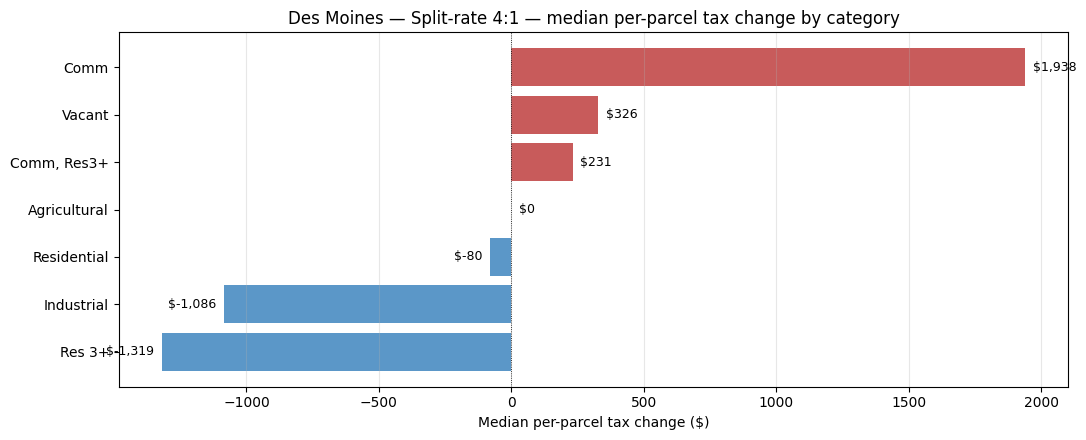

In [12]:
# Chart A: median per-parcel tax change ($) by category (LVT only, no swap).
# Filter to categories with >50 non-exempt parcels for legibility. Includes
# Vacant / Parking Lot / Underdeveloped as their own rows (broken out from
# their Polk class via the chart_category column).
plot_data = summary[summary["property_count"] > 50].copy()
cat_col = "chart_category" if "chart_category" in plot_data.columns else "property_land_use_category"
plot_data = plot_data.sort_values("median_tax_change")

fig, ax = plt.subplots(figsize=(11, max(4.5, len(plot_data) * 0.55)))
colors = ["#c44d4d" if v > 0 else "#4d8ec4" for v in plot_data["median_tax_change"]]
y = np.arange(len(plot_data))
ax.barh(y, plot_data["median_tax_change"], color=colors, alpha=0.92)
ax.axvline(0, color="black", linewidth=0.6, linestyle="dotted")
ax.set_yticks(y)
ax.set_yticklabels(plot_data[cat_col])
ax.set_xlabel("Median per-parcel tax change ($)")
ax.set_title(f"Des Moines — {primary['label']} — median per-parcel tax change by category")
for idx, (_, row) in enumerate(plot_data.iterrows()):
    val = row["median_tax_change"]
    ax.text(
        val + (max(plot_data['median_tax_change'].abs()) * 0.015 * (1 if val >= 0 else -1)),
        idx,
        f"${val:,.0f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=9,
    )
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


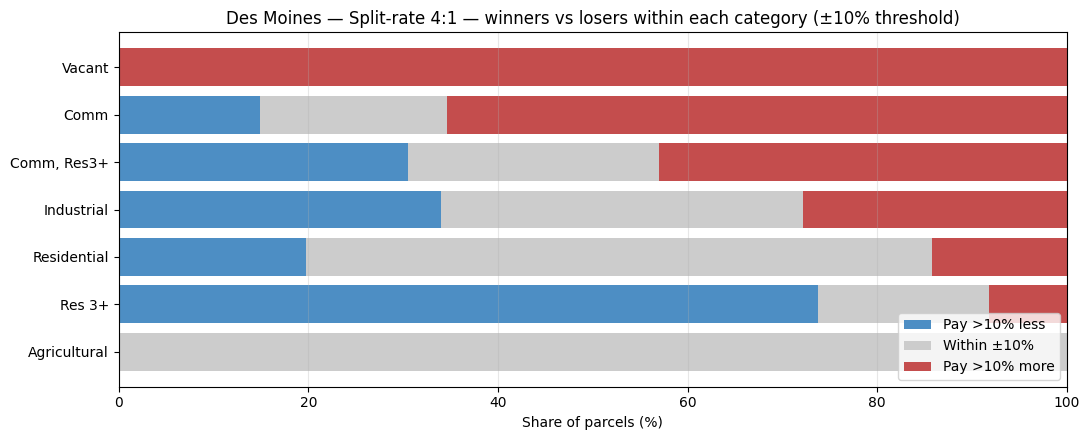

In [13]:
# Chart B: share of parcels paying more vs less, within each category.
# Uses pct_increase_gt_threshold and pct_decrease_gt_threshold from
# calculate_category_tax_summary; the middle band is "within ±10%".
plot_data = summary[summary["property_count"] > 50].copy()
cat_col = "chart_category" if "chart_category" in plot_data.columns else "property_land_use_category"
plot_data["pct_within_threshold"] = 100.0 - plot_data["pct_increase_gt_threshold"] - plot_data["pct_decrease_gt_threshold"]
plot_data = plot_data.sort_values("pct_increase_gt_threshold", ascending=True)

fig, ax = plt.subplots(figsize=(11, max(4.5, len(plot_data) * 0.55)))
y = np.arange(len(plot_data))
ax.barh(y, plot_data["pct_decrease_gt_threshold"], color="#4d8ec4", label="Pay >10% less")
ax.barh(y, plot_data["pct_within_threshold"], left=plot_data["pct_decrease_gt_threshold"],
        color="#cccccc", label="Within ±10%")
ax.barh(y,
        plot_data["pct_increase_gt_threshold"],
        left=plot_data["pct_decrease_gt_threshold"] + plot_data["pct_within_threshold"],
        color="#c44d4d", label="Pay >10% more")
ax.set_yticks(y)
ax.set_yticklabels(plot_data[cat_col])
ax.set_xlabel("Share of parcels (%)")
ax.set_xlim(0, 100)
ax.set_title(f"Des Moines — {primary['label']} — winners vs losers within each category (±10% threshold)")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Refined-category check

`PROPERTY_CATEGORY` flags Vacant / Parking Lot / Underdeveloped parcels. Under
a split-rate LVT we expect these to see the **largest tax increases** because
they have land value but little or no improvement value.

In [14]:
refined_summary = (
    gdf.loc[gdf['exemption_flag']==0]
       .groupby("PROPERTY_CATEGORY", dropna=False)
       .agg(
           n=("parcel_id", "size"),
           current_tax_total=("current_tax", "sum"),
           new_tax_total=("new_tax", "sum"),
           median_change_pct=("tax_change_pct", "median"),
       )
       .sort_values("median_change_pct", ascending=False)
)
refined_summary["delta_total"] = refined_summary["new_tax_total"] - refined_summary["current_tax_total"]
refined_summary


,n,current_tax_total,new_tax_total,median_change_pct,delta_total
PROPERTY_CATEGORY,,,,,
Vacant,1824,2.310830e+06,5.644798e+06,150.314043,3.333967e+06
Underdeveloped,16,3.325668e+05,6.449867e+05,114.197493,3.124199e+05
NaN,44260,3.639417e+08,3.602953e+08,-1.776044,-3.646387e+06


## 10. High-impact parcels

Top 20 tax increases and top 20 tax decreases (absolute dollars). Increases
should concentrate on commercial land with little improvement value; decreases
on improvement-heavy single-family homes.

In [15]:
non_exempt = gdf.loc[gdf['exemption_flag']==0].copy()

top_increase_cols = ["parcel_id", "property_land_use_category", "PROPERTY_CATEGORY",
                     "land_value", "improvement_value", "full_market_value",
                     "current_tax", "new_tax", "tax_change", "tax_change_pct",
                     "tax_district_name", "in_tif"]
top_increase = non_exempt.nlargest(20, "tax_change")[top_increase_cols].copy()
print("Top 20 tax INCREASES (largest dollar payers more under the reform):")
print(top_increase.to_string(index=False))


Top 20 tax INCREASES (largest dollar payers more under the reform):
   parcel_id property_land_use_category PROPERTY_CATEGORY  land_value  improvement_value  full_market_value   current_tax       new_tax    tax_change  tax_change_pct                     tax_district_name  in_tif
792419151018                       Comm              None     8700000            3700000           12400000 473040.525578 912489.575378 439449.049800       92.898816          DES MOINES CITY/JOHNSTON SCH       0
782403301001                       Comm              None     7930000            3570000           11500000 448727.625805 836032.598044 387304.972239       86.311818 DES MOINES CITY/DM SCH/DOWNTOWN SSMID       1
792524426028                       Comm              None     7910000            7090000           15000000 568677.683185 918856.406221 350178.723036       61.577715                DES MOINES CITY/DM SCH       1
782409277011                       Comm              None     6560000            269

In [16]:
top_decrease = non_exempt.nsmallest(20, "tax_change")[top_increase_cols].copy()
print("Top 20 tax DECREASES (largest dollar reductions under the reform):")
print(top_decrease.to_string(index=False))


Top 20 tax DECREASES (largest dollar reductions under the reform):
   parcel_id property_land_use_category PROPERTY_CATEGORY  land_value  improvement_value  full_market_value  current_tax      new_tax     tax_change  tax_change_pct                            tax_district_name  in_tif
782404377001                       Comm              None     3830000           77370000           81200000 3.185290e+06 2.207559e+06 -977730.505004      -30.695180        DES MOINES CITY/DM SCH/DOWNTOWN SSMID       1
782405486010                       Comm              None     8570000           73330000           81900000 3.212773e+06 2.562922e+06 -649851.273056      -20.227112        DES MOINES CITY/DM SCH/DOWNTOWN SSMID       1
782404337002                       Comm              None     5820000           61980000           67800000 2.659179e+06 2.030251e+06 -628927.724258      -23.651199        DES MOINES CITY/DM SCH/DOWNTOWN SSMID       1
782402452017                 Industrial              None    

## 11. Land-use diagnostics

Where does the land value sit before vs. after the reform? Vacant / parking /
underdeveloped categories should see large fractional tax increases relative to
their current bills.

In [17]:
diag = non_exempt.copy()
total_land_area = diag["area_sqft"].sum()
total_market = diag["full_market_value"].sum()

print(f"{'Refined category':<22}{'Parcels':>10}{'Land area % city':>20}{'Mkt value % city':>22}{'Med tax change':>18}{'Med tax chg %':>18}")
print("-" * 110)
for cat, sub in diag.groupby("PROPERTY_CATEGORY", dropna=False):
    label = str(cat) if cat is not None else "(other / built)"
    n = len(sub)
    area_share = sub["area_sqft"].sum() / total_land_area * 100
    mkt_share = sub["full_market_value"].sum() / total_market * 100
    med_change = sub["tax_change"].median()
    med_change_pct = sub["tax_change_pct"].median()
    print(f"{label:<22}{n:>10,}{area_share:>20.2f}{mkt_share:>22.2f}{med_change:>18,.0f}{med_change_pct:>17.1f}%")


Refined category         Parcels    Land area % city      Mkt value % city    Med tax change     Med tax chg %
--------------------------------------------------------------------------------------------------------------
Underdeveloped                16                0.55                  0.06             7,087            114.2%
Vacant                     1,824                9.03                  0.54               301            150.3%
nan                       44,260               90.42                 99.40               -71             -1.8%


## 12. Scenario comparison

Median tax change across the four reform scenarios, by Polk class. The
progression 2:1 → 4:1 → 8:1 → full abatement should show monotonically
larger tax-changes for the high-land-ratio categories.

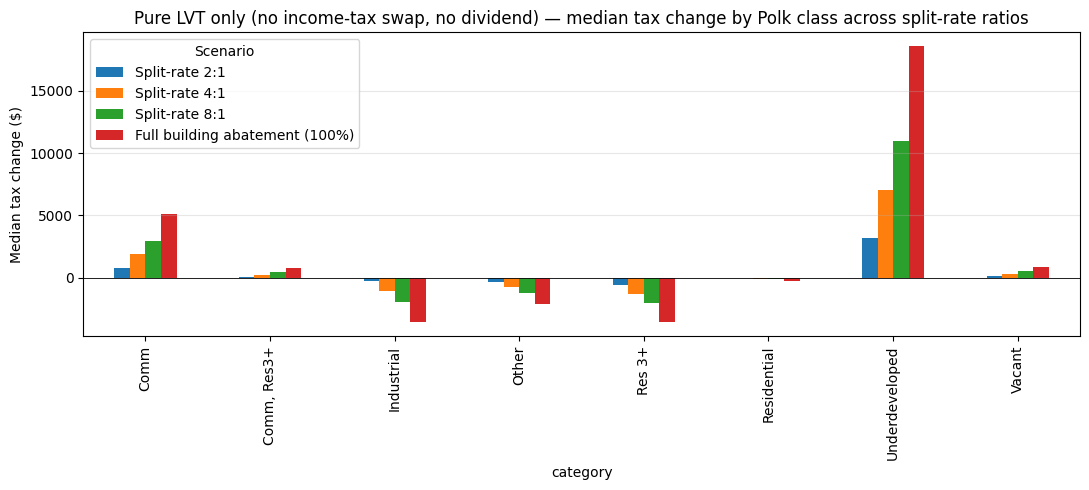

In [18]:
comparison_rows = []
for key, s in scenarios_all.items():
    df_s = s["df"].copy()
    df_s = df_s.loc[df_s["exemption_flag"] == 0]
    df_s["tax_change"] = df_s["new_tax"] - df_s["current_tax"]
    by_cat = df_s.groupby("chart_category")["tax_change"].median()
    for cat, val in by_cat.items():
        comparison_rows.append({"scenario": s["label"], "category": cat, "median_tax_change": val})

scen_df = pd.DataFrame(comparison_rows)
keep_cats = (
    scen_df.groupby("category")["median_tax_change"].apply(lambda v: v.abs().max())
    .sort_values(ascending=False).head(8).index.tolist()
)
plot_data = scen_df[scen_df["category"].isin(keep_cats)]

pivot = plot_data.pivot(index="category", columns="scenario", values="median_tax_change")
pivot = pivot[[s["label"] for s in scenarios_all.values()]]
fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot(kind="bar", ax=ax)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_ylabel("Median tax change ($)")
ax.set_title("Pure LVT only (no income-tax swap, no dividend) — median tax change by Polk class across split-rate ratios")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Scenario", loc="best")
plt.tight_layout()
plt.show()


## 13. Equity overlay — Census ACS

Spatial-join parcels to Polk County (FIPS 19153) block groups and bucket by
median household income quintile. Tax change should be roughly progressive
under a split-rate LVT (high-income, improvement-heavy parcels see modest
decreases; low-income vacant/under-built parcels see modest increases) but
the picture is sensitive to whether the buckets are dominated by commercial
vs residential.

Requires a `CENSUS_API_KEY` env var (free: https://api.census.gov/data/key_signup.html).


In [19]:
import os

if not os.getenv("CENSUS_API_KEY"):
    print("CENSUS_API_KEY not set — skipping equity overlay.")
    equity_ready = False
else:
    # census_utils is already imported at the top via `from lvt import ...`.
    census_data, census_boundaries = census_utils.get_census_data_with_boundaries(
        fips_code="19153",
        year=2022,
    )
    matched = census_utils.match_to_census_blockgroups(non_exempt.copy(), census_boundaries)
    if "median_income" not in matched.columns and "GEOID" in matched.columns:
        matched = matched.merge(census_data, on="GEOID", how="left")

    # Supplemental ACS pull (block-group level):
    #   B25077 — Median value of owner-occupied housing units (wealth proxy).
    #            Home equity is ~70% of net worth for typical US households
    #            (Survey of Consumer Finances). Only owner-occupied units;
    #            renter-majority BGs reflect landlord values not tenant wealth.
    #   B25003 — Tenure (total occupied / renter-occupied housing units).
    #            Lets us quintile parcels by their BG's renter share.
    import requests as _r
    _resp = _r.get(
        "https://api.census.gov/data/2022/acs/acs5",
        params={
            "get": "B25077_001E,B25003_001E,B25003_003E,GEO_ID",
            "for": "block group:*",
            "in": "state:19 county:153",
            "key": os.getenv("CENSUS_API_KEY", ""),
        },
        timeout=30,
    )
    _resp.raise_for_status()
    _data = _resp.json()
    _bg_extras = pd.DataFrame(_data[1:], columns=_data[0])
    _bg_extras["std_geoid"] = (
        _bg_extras["state"] + _bg_extras["county"] + _bg_extras["tract"] + _bg_extras["block group"]
    )
    _bg_extras["median_home_value"] = pd.to_numeric(_bg_extras["B25077_001E"], errors="coerce")
    _bg_total = pd.to_numeric(_bg_extras["B25003_001E"], errors="coerce")
    _bg_renter = pd.to_numeric(_bg_extras["B25003_003E"], errors="coerce")
    _bg_extras["renter_share"] = (_bg_renter / _bg_total.replace(0, np.nan)).clip(0, 1)
    matched = matched.merge(
        _bg_extras[["std_geoid", "median_home_value", "renter_share"]],
        on="std_geoid", how="left",
    )

    print(f"Matched {len(matched):,} parcels to Polk block groups")
    print(f"With median_income available:     {matched['median_income'].notna().sum():,}")
    print(f"With median_home_value available: {matched['median_home_value'].notna().sum():,}")
    print(f"With renter_share available:      {matched['renter_share'].notna().sum():,}")
    equity_ready = "median_income" in matched.columns and matched['median_income'].notna().sum() > 0
    wealth_ready = "median_home_value" in matched.columns and matched['median_home_value'].notna().sum() > 0
    renter_ready = "renter_share" in matched.columns and matched['renter_share'].notna().sum() > 0


Matched 46,100 parcels to Polk block groups
With median_income available:     46,100
With median_home_value available: 46,100
With renter_share available:      46,100


In [20]:
if equity_ready:
    income_data = matched.loc[matched["median_income"].notna()].copy()
    income_data["income_quintile"] = pd.qcut(
        income_data["median_income"], q=5,
        labels=["Q1 (lowest income)", "Q2", "Q3", "Q4", "Q5 (highest income)"]
    )
    income_summary = (
        income_data.groupby("income_quintile", observed=True)
        .agg(
            n=("parcel_id", "size"),
            current_tax_total=("current_tax", "sum"),
            new_tax_total=("new_tax", "sum"),
            median_tax_change=("tax_change", "median"),
            median_tax_change_pct=("tax_change_pct", "median"),
        )
    )
    income_summary["delta_total"] = income_summary["new_tax_total"] - income_summary["current_tax_total"]
    income_summary["delta_pct"] = (income_summary["delta_total"] / income_summary["current_tax_total"]) * 100
    print(income_summary.to_string())
else:
    print("(equity table skipped)")


                        n  current_tax_total  new_tax_total  median_tax_change  median_tax_change_pct   delta_total  delta_pct
income_quintile                                                                                                               
Q1 (lowest income)   9603       9.092365e+07   8.907264e+07        -105.061266              -3.146928 -1.851007e+06  -2.035782
Q2                   8962       9.090967e+07   8.988808e+07         -68.796842              -2.044230 -1.021597e+06  -1.123750
Q3                   9274       6.153629e+07   6.355164e+07         -79.164953              -2.257106  2.015348e+06   3.275056
Q4                   9051       5.207266e+07   5.292559e+07           0.246117               0.006483  8.529375e+05   1.637976
Q5 (highest income)  9210       7.114284e+07   7.114715e+07           7.149645               0.203061  4.318428e+03   0.006070


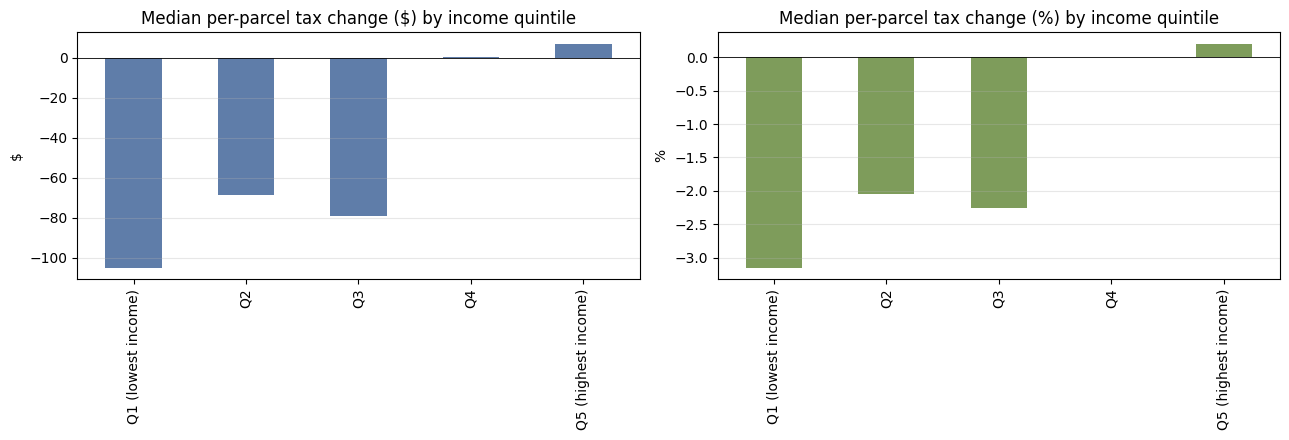

In [21]:
if equity_ready:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    income_summary["median_tax_change"].plot(kind="bar", ax=axes[0], color="#5f7da9")
    axes[0].set_title("Median per-parcel tax change ($) by income quintile")
    axes[0].set_ylabel("$")
    axes[0].axhline(0, color="black", linewidth=0.6)
    axes[0].set_xlabel("")
    axes[0].grid(axis="y", alpha=0.3)

    income_summary["median_tax_change_pct"].plot(kind="bar", ax=axes[1], color="#7e9c5b")
    axes[1].set_title("Median per-parcel tax change (%) by income quintile")
    axes[1].set_ylabel("%")
    axes[1].axhline(0, color="black", linewidth=0.6)
    axes[1].set_xlabel("")
    axes[1].grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


### Same picture by wealth quintile (ACS B25077 median home value)

Parcels bucketed into wealth quintiles by the **median value of owner-occupied
housing units in their block group**. Q1 = lowest-wealth BGs, Q5 = highest.
This is a different lens than income — wealth and income correlate but the
distribution shapes differ (younger high earners with low net worth in Q5 of
income but Q1-2 of wealth; older retirees with paid-off homes are the
opposite).

In [22]:
if wealth_ready:
    wealth_data = matched.loc[matched["median_home_value"].notna() & (matched["median_home_value"] > 0)].copy()
    wealth_data["wealth_quintile"] = pd.qcut(
        wealth_data["median_home_value"], q=5,
        labels=["Q1 (lowest wealth)", "Q2", "Q3", "Q4", "Q5 (highest wealth)"]
    )
    wealth_summary = (
        wealth_data.groupby("wealth_quintile", observed=True)
        .agg(
            n=("parcel_id", "size"),
            current_tax_total=("current_tax", "sum"),
            new_tax_total=("new_tax", "sum"),
            median_tax_change=("tax_change", "median"),
            median_tax_change_pct=("tax_change_pct", "median"),
        )
    )
    wealth_summary["delta_total"] = wealth_summary["new_tax_total"] - wealth_summary["current_tax_total"]
    wealth_summary["delta_pct"] = (wealth_summary["delta_total"] / wealth_summary["current_tax_total"]) * 100
    print(wealth_summary.to_string())
else:
    print("(wealth table skipped)")


                        n  current_tax_total  new_tax_total  median_tax_change  median_tax_change_pct   delta_total  delta_pct
wealth_quintile                                                                                                               
Q1 (lowest wealth)   9186       5.713593e+07   5.367385e+07         -83.783869              -2.960938 -3.462081e+06  -6.059377
Q2                   9254       5.246357e+07   5.124459e+07        -126.078785              -3.573428 -1.218980e+06  -2.323479
Q3                   8784       5.029874e+07   5.269290e+07          -4.963156              -0.142607  2.394162e+06   4.759884
Q4                   9330       6.062313e+07   6.096768e+07          -1.460132              -0.032325  3.445478e+05   0.568344
Q5 (highest wealth)  8772       1.305573e+08   1.308868e+08          -0.698246              -0.017742  3.295142e+05   0.252391


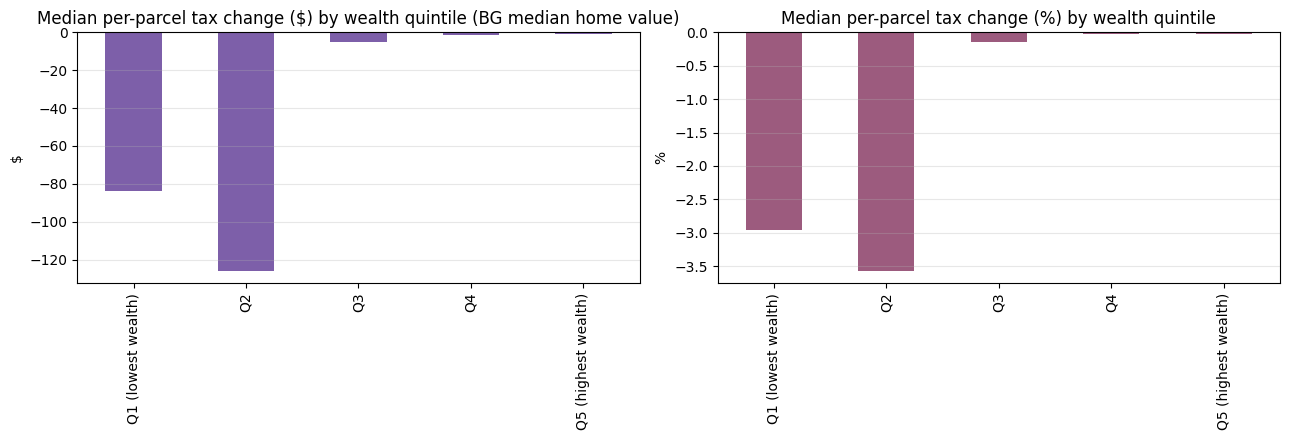

In [23]:
if wealth_ready:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    wealth_summary["median_tax_change"].plot(kind="bar", ax=axes[0], color="#7d5fa9")
    axes[0].set_title("Median per-parcel tax change ($) by wealth quintile (BG median home value)")
    axes[0].set_ylabel("$")
    axes[0].axhline(0, color="black", linewidth=0.6)
    axes[0].set_xlabel("")
    axes[0].grid(axis="y", alpha=0.3)

    wealth_summary["median_tax_change_pct"].plot(kind="bar", ax=axes[1], color="#9c5b7e")
    axes[1].set_title("Median per-parcel tax change (%) by wealth quintile")
    axes[1].set_ylabel("%")
    axes[1].axhline(0, color="black", linewidth=0.6)
    axes[1].set_xlabel("")
    axes[1].grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


### Same picture by renter quintile (ACS B25003 — renter share of occupied units)

Parcels bucketed by their block group's **renter share** (Q1 = lowest renter
share / mostly owner-occupied neighborhoods; Q5 = highest renter share /
mostly renter neighborhoods).

**Caveat on interpretation:** the chart shows per-parcel tax change, which
legally falls on the *parcel owner* (i.e., the landlord in a renter-heavy
BG). Economic incidence — whether and how the landlord passes the
property-tax change through to rent — is not modeled. So this chart most
honestly reads as "how does the **landlord-side** burden shift across
high-renter vs low-renter neighborhoods," not as "how do renters fare."

Renters' direct benefit shows up in the swap and dividend layers (§14, §15)
via the per-resident income-tax-savings and dividend allocations.

In [24]:
if renter_ready:
    renter_data = matched.loc[matched["renter_share"].notna()].copy()
    renter_data["renter_quintile"] = pd.qcut(
        renter_data["renter_share"], q=5,
        labels=["Q1 (low renter share)", "Q2", "Q3", "Q4", "Q5 (high renter share)"],
        duplicates="drop",
    )
    renter_summary = (
        renter_data.groupby("renter_quintile", observed=True)
        .agg(
            n=("parcel_id", "size"),
            mean_renter_share=("renter_share", "mean"),
            current_tax_total=("current_tax", "sum"),
            new_tax_total=("new_tax", "sum"),
            median_tax_change=("tax_change", "median"),
            median_tax_change_pct=("tax_change_pct", "median"),
        )
    )
    renter_summary["delta_total"] = renter_summary["new_tax_total"] - renter_summary["current_tax_total"]
    renter_summary["delta_pct"] = (renter_summary["delta_total"] / renter_summary["current_tax_total"]) * 100
    print(renter_summary.to_string())
else:
    print("(renter table skipped)")


                           n  mean_renter_share  current_tax_total  new_tax_total  median_tax_change  median_tax_change_pct   delta_total  delta_pct
renter_quintile                                                                                                                                     
Q1 (low renter share)   9430           0.044162       5.498565e+07   5.702829e+07         -27.395282              -0.615588  2.042636e+06   3.714853
Q2                      9121           0.167023       6.124363e+07   5.920586e+07         -15.839909              -0.357642 -2.037774e+06  -3.327324
Q3                      9239           0.270920       4.932078e+07   4.918688e+07         -35.303881              -0.961273 -1.339006e+05  -0.271489
Q4                      9181           0.401688       5.567452e+07   5.720528e+07         -48.487061              -1.374006  1.530761e+06   2.749481
Q5 (high renter share)  9129           0.681341       1.453605e+08   1.439588e+08        -143.569072      

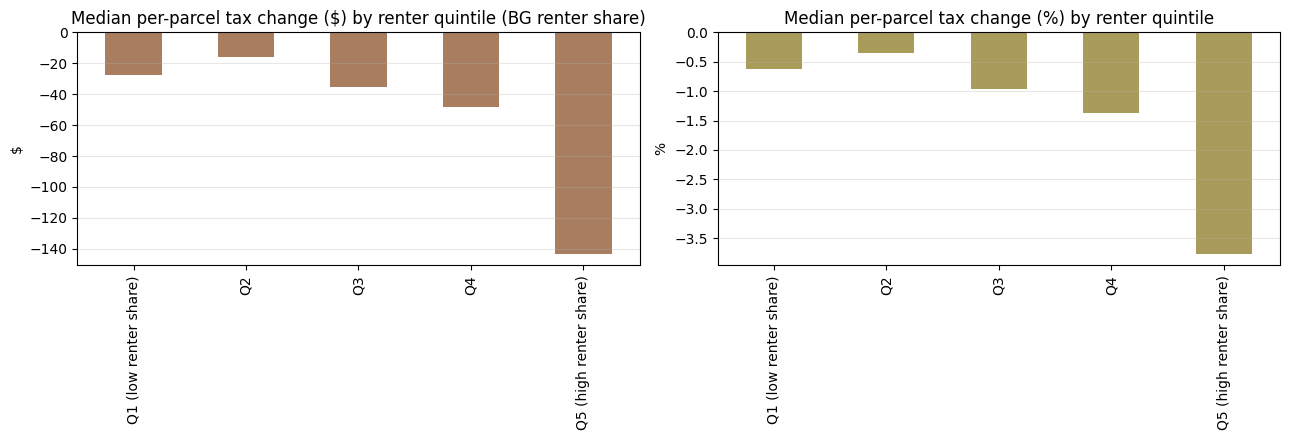

In [25]:
if renter_ready:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    renter_summary["median_tax_change"].plot(kind="bar", ax=axes[0], color="#a97d5f")
    axes[0].set_title("Median per-parcel tax change ($) by renter quintile (BG renter share)")
    axes[0].set_ylabel("$")
    axes[0].axhline(0, color="black", linewidth=0.6)
    axes[0].set_xlabel("")
    axes[0].grid(axis="y", alpha=0.3)

    renter_summary["median_tax_change_pct"].plot(kind="bar", ax=axes[1], color="#a99c5b")
    axes[1].set_title("Median per-parcel tax change (%) by renter quintile")
    axes[1].set_ylabel("%")
    axes[1].axhline(0, color="black", linewidth=0.6)
    axes[1].set_xlabel("")
    axes[1].grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


## 14. Income tax abolition swap (per-household block-group weighted)

A more aggressive policy: alongside the property-tax-shift-to-land, **eliminate
the Iowa state personal income tax entirely** and recover the lost revenue
through additional property tax on the same DM parcels.

### Methodology

Two parallel allocations, summed per parcel:

**Personal income tax → residential + agricultural parcels** (farm income files
through personal income tax via Schedule F, so ag-class parcels share this
burden):

1. Allocate Iowa's personal income tax to DM block groups in proportion to
   each block group's ACS aggregate household income (B19313).
2. Within each block group, distribute the allocated burden across
   residential and agricultural parcels weighted by full market value.

**Corporate income tax → commercial + industrial + utility parcels** (citywide,
since corporations don't "live" in a block group the way households do):

3. Allocate Iowa's corporate income tax to DM by DM's share of statewide
   corporate property assessed value, distributed across DM commercial /
   industrial / utility parcels weighted by full market value.

Then:

4. New citywide property-tax target = current property tax + sum of allocated
   per-parcel personal + corporate income-tax burdens.
5. Re-run all four reform scenarios (split-rate 2:1, 4:1, 8:1, full building
   abatement) at the higher target.
6. For each parcel: **net effect** = (new property tax under swap) −
   (current property tax + current income tax burden). Negative = the
   household / business comes out ahead under the swap.

### Caveats

- Iowa income-tax constants are the **March 2026 REC FY26 forecast** numbers
  (linked above). Re-pull from the December REC if a fresher view is wanted.
- ACS aggregate income (B19313) is a 5-year survey estimate, vintage 2022.
  It's a proxy for AGI, not AGI itself. Difference is small at the
  citywide level.
- The corporate side is a coarse proxy. Iowa corporate income tax falls on
  C-corps; pass-through entities (S-corps, LLCs, partnerships) flow through
  to personal income tax instead. We split by the IRS statutory dimension
  (personal vs corporate) rather than by Iowa-specific entity counts.
- Excluded: post-tax credits, withholding-vs-payment timing, federal
  deductibility effects. Per the modeling guide these are preserved by the
  reform and don't affect the revenue-neutral solve.

In [26]:
# Iowa Revenue Estimating Conference (REC) FY 2026 forecast.
# Source: March 2026 REC, "Estimate of General Fund Receipts" PDF.
# https://dom.iowa.gov/news/2026-03-12/march-2026-estimate-general-fund-receipts
# Re-pull annually after the December REC meeting if a fresher number is wanted.
IOWA_PERSONAL_INCOME_TAX_FY26 = 4_307_500_000   # "Personal Inc. Tax", Mar 26 REC FY 26 Est
IOWA_CORPORATE_INCOME_TAX_FY26 = 636_200_000    # "Corporate Income Tax", Mar 26 REC FY 26 Est
IOWA_TOTAL_INCOME_TAX_FY26 = IOWA_PERSONAL_INCOME_TAX_FY26 + IOWA_CORPORATE_INCOME_TAX_FY26

# Iowa statewide aggregate household income — live fetch from ACS so we never
# drift from the block-group data the rest of the notebook uses. Census API
# B19313 is the same Aggregate Household Income table we pull below at the
# block-group level; here we just pull state-level for normalization.
import os, requests as _r
_acs_year = 2022  # matches the per-BG fetch (census Python lib's TIGER vintage list ends 2022)
_resp = _r.get(
    f"https://api.census.gov/data/{_acs_year}/acs/acs5",
    params={
        "get": "B19313_001E,B11001_001E",
        "for": "state:19",
        "key": os.getenv("CENSUS_API_KEY", ""),
    },
    timeout=30,
)
_resp.raise_for_status()
_data = _resp.json()
IOWA_AGGREGATE_HH_INCOME = int(_data[1][0])
IOWA_HOUSEHOLDS = int(_data[1][1])

print(f"Iowa personal income tax FY26 (REC):       ${IOWA_PERSONAL_INCOME_TAX_FY26:>15,.0f}")
print(f"Iowa corporate income tax FY26 (REC):      ${IOWA_CORPORATE_INCOME_TAX_FY26:>15,.0f}")
print(f"Iowa total income tax FY26 (swap target):  ${IOWA_TOTAL_INCOME_TAX_FY26:>15,.0f}")
print(f"Iowa aggregate HH income ({_acs_year} 5-yr ACS): ${IOWA_AGGREGATE_HH_INCOME:>15,.0f}")
print(f"Iowa households ({_acs_year} 5-yr ACS):           {IOWA_HOUSEHOLDS:>15,}")
print(f"Implied personal-tax effective rate on HH AGI: {IOWA_PERSONAL_INCOME_TAX_FY26/IOWA_AGGREGATE_HH_INCOME*100:>5.2f}%")


Iowa personal income tax FY26 (REC):       $  4,307,500,000
Iowa corporate income tax FY26 (REC):      $    636,200,000
Iowa total income tax FY26 (swap target):  $  4,943,700,000
Iowa aggregate HH income (2022 5-yr ACS): $121,014,078,600
Iowa households (2022 5-yr ACS):                 1,290,139
Implied personal-tax effective rate on HH AGI:  3.56%


In [27]:
# Pull per-block-group aggregate household income (B19313) for Polk County.
# Uses the Census API directly — census_utils.get_census_data_with_boundaries
# returns median + racial breakdowns but not aggregate income.
import os
import requests

swap_ready = equity_ready and bool(os.getenv("CENSUS_API_KEY"))
if not swap_ready:
    print("Skipping swap section: needs the equity overlay matched + CENSUS_API_KEY.")
else:
    api_key = os.getenv("CENSUS_API_KEY")
    url = "https://api.census.gov/data/2022/acs/acs5"
    params = {
        "get": "B19313_001E,B11001_001E,B01003_001E,GEO_ID",
        "for": "block group:*",
        "in": "state:19 county:153",
        "key": api_key,
    }
    resp = requests.get(url, params=params, timeout=60)
    resp.raise_for_status()
    data = resp.json()
    bg_extra = pd.DataFrame(data[1:], columns=data[0])
    # census_utils returns std_geoid as 12-char block group ID; match it
    # exactly by concatenating the four ACS geo fields.
    bg_extra["std_geoid"] = (
        bg_extra["state"] + bg_extra["county"] + bg_extra["tract"] + bg_extra["block group"]
    )
    bg_extra["aggregate_hh_income"] = pd.to_numeric(bg_extra["B19313_001E"], errors="coerce").clip(lower=0)
    bg_extra["households"] = pd.to_numeric(bg_extra["B11001_001E"], errors="coerce").clip(lower=0)
    bg_extra["bg_total_pop"] = pd.to_numeric(bg_extra["B01003_001E"], errors="coerce").clip(lower=0)
    bg_extra = bg_extra[["std_geoid", "aggregate_hh_income", "households", "bg_total_pop"]]
    print(f"Pulled supplemental ACS for {len(bg_extra)} Polk block groups")
    print(f"  block groups with aggregate income > 0: {(bg_extra['aggregate_hh_income'] > 0).sum()}")

    # Merge supplemental into the existing matched DataFrame via std_geoid.
    swap_df = matched.merge(bg_extra, on="std_geoid", how="left")
    swap_df["aggregate_hh_income"] = swap_df["aggregate_hh_income"].fillna(0)
    swap_df["households"] = swap_df["households"].fillna(0)
    swap_df["bg_total_pop"] = swap_df["bg_total_pop"].fillna(0)
    print(f"  Parcels with non-zero block-group aggregate income: {(swap_df['aggregate_hh_income'] > 0).sum():,} / {len(swap_df):,}")
    dm_total_agi = swap_df.drop_duplicates(subset=["std_geoid"])["aggregate_hh_income"].sum()
    print(f"  DM aggregate household income (sum of matched BGs): ${dm_total_agi:,.0f}")
    print(f"  DM share of Iowa total AGI:                          {dm_total_agi / IOWA_AGGREGATE_HH_INCOME * 100:.2f}%")


Pulled supplemental ACS for 336 Polk block groups
  block groups with aggregate income > 0: 335
  Parcels with non-zero block-group aggregate income: 46,100 / 46,100
  DM aggregate household income (sum of matched BGs): $7,615,936,500
  DM share of Iowa total AGI:                          6.29%


### LEHD LODES — block-level jobs (for spatial corporate-tax allocation)

The corporate-income-tax piece of the swap is allocated to DM parcels by
**job density at the census block level** rather than spread citywide-flat.
We pull Workplace Area Characteristics (WAC) from
[LEHD LODES8 IA WAC 2022](https://lehd.ces.census.gov/data/lodes/LODES8/ia/wac/)
— each block has a total-jobs count (`C000`) and a NAICS-2-digit sector
breakdown (`CNS01`..`CNS20`).

We sum the **non-government/non-nonprofit sectors** (excluding educational
services CNS15, health care CNS16, and public administration CNS20) into
`eligible_jobs` — these are the sectors that actually generate
corporate-income-tax revenue at any meaningful scale. Then we allocate
DM's corporate-tax burden proportional to `parcel_value × block_eligible_jobs`,
restricted to commercial / industrial / utility parcels.

The Iowa DOR's Corporation Income Tax Statistical Report **does not include
a NAICS sector breakdown** (we checked the 2023 release — its appendix
tables are all organized by income bracket). If you find a per-sector
Iowa-specific corporate-tax-paid table (e.g., from IRS SOI Publication 16
applied to Iowa), it would slot in here as a per-sector multiplier on the
LODES jobs counts. For now we treat all "eligible" sectors as paying
corporate tax proportional to their job count.

In [28]:
if swap_ready:
    LODES_YEAR = 2022
    # lodes_utils handles the LEHD fetch + 15-char GEOID padding + cache.
    # DEFAULT_EXCLUDED_SECTORS = {CNS15 education, CNS16 health, CNS20 public admin}.
    lodes = lodes_utils.fetch_lodes_wac(state="ia", year=LODES_YEAR, cache_dir=data_dir)
    lodes = lodes_utils.compute_eligible_jobs(lodes)
    lodes["GEOID"] = lodes["w_geocode"]
    lodes_blocks = lodes[["GEOID", "C000", "eligible_jobs"]].rename(columns={"C000": "block_total_jobs"})

    # Merge into swap_df via 15-char block GEOID (already on `matched`).
    if "GEOID" not in swap_df.columns and "GEOID" in matched.columns:
        swap_df = swap_df.merge(matched[["parcel_id", "GEOID"]], on="parcel_id", how="left")
    swap_df["GEOID"] = swap_df["GEOID"].astype(str)
    swap_df = swap_df.merge(lodes_blocks, on="GEOID", how="left")
    swap_df["block_total_jobs"] = swap_df["block_total_jobs"].fillna(0)
    swap_df["eligible_jobs"] = swap_df["eligible_jobs"].fillna(0)

    dm_block_summary = swap_df.drop_duplicates(subset=["GEOID"])
    print()
    print(f"Distinct DM blocks matched to LODES:      {(dm_block_summary['block_total_jobs'] > 0).sum():,}")
    print(f"DM total jobs (sum C000 across blocks):   {dm_block_summary['block_total_jobs'].sum():,.0f}")
    print(f"DM eligible (corp-tax) jobs:              {dm_block_summary['eligible_jobs'].sum():,.0f}")
    print(f"  ({dm_block_summary['eligible_jobs'].sum() / dm_block_summary['block_total_jobs'].sum() * 100:.1f}% of total jobs in eligible sectors)")



Distinct DM blocks matched to LODES:      1,262
DM total jobs (sum C000 across blocks):   112,209
DM eligible (corp-tax) jobs:              85,415
  (76.1% of total jobs in eligible sectors)


In [29]:
if swap_ready:
    # --------------------------------------------------------------------
    # PERSONAL income tax → residential + agricultural parcels
    # --------------------------------------------------------------------
    # Allocate Iowa's personal income tax to DM block groups in proportion to
    # each BG's aggregate household income. Within each BG, distribute that
    # BG-level burden across residential AND agricultural parcels weighted by
    # full market value. (Group on std_geoid — 12-char block group; NOT
    # GEOID — 15-char block — otherwise the sum repeats per block.)
    swap_df["bg_personal_burden"] = (
        swap_df["aggregate_hh_income"] / IOWA_AGGREGATE_HH_INCOME
        * IOWA_PERSONAL_INCOME_TAX_FY26
    )
    # Ag is carved out of the LVT solve, so ag parcels do NOT absorb income
    # tax replacement burden. Ag farmers still benefit from the abolition
    # (Schedule F filers save) but the burden falls only on residential
    # parcels. Residential-in-mixed-BGs absorb ag's would-be share.
    personal_buckets = {"residential"}
    is_household = swap_df["rollback_bucket"].isin(personal_buckets)
    swap_df["_household_value"] = swap_df["full_market_value"].where(is_household, 0.0)
    bg_household_sum = (
        swap_df.groupby("std_geoid")["_household_value"].transform("sum").replace(0, np.nan)
    )
    swap_df["parcel_personal_burden"] = (
        swap_df["bg_personal_burden"] * swap_df["_household_value"] / bg_household_sum
    ).fillna(0.0)

    # --------------------------------------------------------------------
    # CORPORATE income tax → commercial + industrial + utility parcels,
    # spatially weighted by LODES block-level eligible jobs.
    # --------------------------------------------------------------------
    # DM's share of Iowa corporate tax is proxied by DM's share of statewide
    # AGI (same proxy as the personal side; we don't have a per-county IA DoR
    # corporate-tax-paid table). Within DM, allocation is by
    # parcel_value × block_eligible_jobs — so commercial parcels in
    # high-job-density blocks (downtown, Westown, Capitol East) absorb more
    # than commercial parcels in low-job-density blocks (small retail in a
    # mostly-residential block).
    corporate_buckets = {"commercial", "utility"}
    is_corporate = swap_df["rollback_bucket"].isin(corporate_buckets)
    dm_personal_share = float(swap_df["parcel_personal_burden"].sum()) / IOWA_PERSONAL_INCOME_TAX_FY26
    dm_corporate_burden_total = dm_personal_share * IOWA_CORPORATE_INCOME_TAX_FY26

    # lodes_utils.allocate_by_jobs_and_value handles the
    # parcel_value × block_eligible_jobs weighting with a flat-by-value
    # fallback if the LODES merge produced zero jobs everywhere.
    # The swap_df already has block-level eligible_jobs merged in (above),
    # so we pass swap_df itself as both the parcels frame and the lookup table.
    swap_df["parcel_corporate_burden"] = lodes_utils.allocate_by_jobs_and_value(
        parcels_df=swap_df,
        lodes_df=swap_df[["GEOID", "eligible_jobs"]].drop_duplicates(subset=["GEOID"]),
        total_dollars=dm_corporate_burden_total,
        parcel_value_col="full_market_value",
        target_mask=is_corporate,
        parcel_block_col="GEOID",
        lodes_block_col="GEOID",
        lodes_jobs_col="eligible_jobs",
    )

    swap_df["parcel_income_tax_burden"] = (
        swap_df["parcel_personal_burden"] + swap_df["parcel_corporate_burden"]
    )

    total_personal = float(swap_df["parcel_personal_burden"].sum())
    total_corporate = float(swap_df["parcel_corporate_burden"].sum())
    total_swap_burden = total_personal + total_corporate

    print("DM allocated income-tax burden:")
    print(f"  Personal (residential + ag):    ${total_personal:>15,.0f}    ({total_personal/IOWA_PERSONAL_INCOME_TAX_FY26*100:5.2f}% of IA personal)")
    print(f"  Corporate (commercial + util):  ${total_corporate:>15,.0f}    ({total_corporate/IOWA_CORPORATE_INCOME_TAX_FY26*100:5.2f}% of IA corporate)")
    print(f"  Total swap burden:              ${total_swap_burden:>15,.0f}")
    print()
    print("Per-parcel burden by bucket:")
    for label, mask in [
        ("residential", swap_df["rollback_bucket"] == "residential"),
        ("agricultural", swap_df["rollback_bucket"] == "agricultural"),
        ("commercial", swap_df["rollback_bucket"] == "commercial"),
        ("utility", swap_df["rollback_bucket"] == "utility"),
    ]:
        sub = swap_df.loc[mask, "parcel_income_tax_burden"]
        if len(sub):
            print(f"  {label:<14} n={len(sub):>6,}  median ${sub.median():>10,.0f}   mean ${sub.mean():>10,.0f}")


DM allocated income-tax burden:
  Personal (residential + ag):    $    269,057,394    ( 6.25% of IA personal)
  Corporate (commercial + util):  $     39,738,668    ( 6.25% of IA corporate)
  Total swap burden:              $    308,796,062

Per-parcel burden by bucket:
  residential    n=43,413  median $     3,756   mean $     6,198
  agricultural   n=   110  median $         0   mean $         0
  commercial     n= 2,544  median $       252   mean $    15,621
  utility        n=    33  median $         0   mean $         0


In [30]:
if swap_ready:
    # New revenue target = current property tax + allocated income tax.
    swap_target_revenue = total_revenue + total_swap_burden
    print(f"Current property tax revenue:               ${total_revenue:>15,.0f}")
    print(f"Allocated income tax burden (added):        ${total_swap_burden:>15,.0f}")
    print(f"New property tax target under swap:         ${swap_target_revenue:>15,.0f}")
    print(f"Burden multiplier (new / current):          {swap_target_revenue / total_revenue:.3f}x")

    # Re-run all four scenarios against the augmented target. The solver
    # operates on `taxable_land_value` / `taxable_improvement_value` we
    # computed earlier, so we feed the per-parcel taxable values back in.
    # model_split_rate_tax internally calls calculate_category_tax_summary
    # which needs `current_tax` on the input df (the pre-swap baseline).
    # Carry it through so the solver can print/compute its own category summary
    # without crashing.
    swap_input = gdf[[
        "parcel_id", "taxable_land_value", "taxable_improvement_value", "exemption_flag",
        "PROPERTY_CATEGORY", "property_land_use_category", "chart_category", "current_tax",
    ]].merge(
        swap_df[["parcel_id", "parcel_income_tax_burden"]], on="parcel_id", how="left"
    )
    swap_input["parcel_income_tax_burden"] = swap_input["parcel_income_tax_burden"].fillna(0.0)

    scenarios_swap = run_scenarios(swap_input, swap_target_revenue)
    print()
    print(f"{'Scenario':<35}{'Land mills (swap)':>20}{'Imp mills (swap)':>20}{'Revenue':>18}")
    print("-" * 93)
    for key, s in scenarios_swap.items():
        print(f"{s['label']:<35}{s['land_millage']:>20.4f}{s['improvement_millage']:>20.4f}{s['new_revenue']:>18,.0f}")


Current property tax revenue:               $    366,585,112
Allocated income tax burden (added):        $    308,796,062
New property tax target under swap:         $    675,381,174
Burden multiplier (new / current):          1.842x
Building abatement model (100.0% abatement)
Millage rate: 386.5364
Total tax revenue: $674,980,583.89
Target revenue: $674,980,583.89
Revenue difference: $0.00 (0.0000%)

Scenario                              Land mills (swap)    Imp mills (swap)           Revenue
---------------------------------------------------------------------------------------------
Split-rate 2:1                                 130.6441             65.3220       675,381,174
Split-rate 4:1                                 195.2846             48.8211       675,381,174
Split-rate 8:1                                 259.4771             32.4346       675,381,174
Full building abatement (100%)                 386.5364              0.0000       675,381,174


In [31]:
if swap_ready:
    # Side-by-side: pure LVT (current revenue) vs LVT+swap (current+income tax).
    print(f"{'Scenario':<35}{'Land mills (pure)':>20}{'Land mills (swap)':>20}{'Multiplier':>14}")
    print("-" * 89)
    for key in scenarios_all:
        a = scenarios_all[key]["land_millage"]
        b = scenarios_swap[key]["land_millage"]
        mult = b / a if a > 0 else 0
        print(f"{scenarios_all[key]['label']:<35}{a:>20.4f}{b:>20.4f}{mult:>14.3f}x")


Scenario                              Land mills (pure)   Land mills (swap)    Multiplier
-----------------------------------------------------------------------------------------
Split-rate 2:1                                  70.8759            130.6441         1.843x
Split-rate 4:1                                 105.9441            195.2846         1.843x
Split-rate 8:1                                 140.7692            259.4771         1.843x
Full building abatement (100%)                 209.7003            386.5364         1.843x


In [32]:
if swap_ready:
    # Per-parcel net effect under the primary scenario (4:1 split-rate).
    # parcel_income_tax_burden flowed into the solver via swap_input and is
    # preserved on the result df; no re-merge needed.
    primary_swap = scenarios_swap[primary_key]
    swap_result = primary_swap["df"].merge(
        gdf[["parcel_id", "current_tax"]].rename(columns={"current_tax": "current_property_tax"}),
        on="parcel_id", how="left",
    )
    swap_result["parcel_income_tax_burden"] = swap_result["parcel_income_tax_burden"].fillna(0.0)
    swap_result["new_property_tax_under_swap"] = swap_result["new_tax"]
    swap_result["property_tax_change_under_swap"] = (
        swap_result["new_property_tax_under_swap"] - swap_result["current_property_tax"]
    )
    # Net effect: positive = parcel pays MORE total under the swap;
    # negative = parcel comes out ahead (income tax savings exceed property tax increase).
    swap_result["swap_net_change"] = (
        swap_result["property_tax_change_under_swap"]
        - swap_result["parcel_income_tax_burden"]
    )
    swap_result_nonexempt = swap_result.loc[swap_result["exemption_flag"] == 0].copy()
    print(f"Per-parcel net effect of LVT + income tax abolition ({primary_swap['label']}):")
    print(swap_result_nonexempt["swap_net_change"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())
    print()
    print(f"Parcels coming out AHEAD under the swap: {(swap_result_nonexempt['swap_net_change'] < 0).sum():,}"
          f" ({(swap_result_nonexempt['swap_net_change'] < 0).mean()*100:.1f}%)")
    print(f"Parcels paying MORE under the swap:      {(swap_result_nonexempt['swap_net_change'] > 0).sum():,}"
          f" ({(swap_result_nonexempt['swap_net_change'] > 0).mean()*100:.1f}%)")


Per-parcel net effect of LVT + income tax abolition (Split-rate 4:1):
count    4.610000e+04
mean     2.121234e-12
std      5.043127e+04
min     -6.905313e+06
5%      -7.711167e+03
25%     -2.238451e+03
50%     -4.020329e+02
75%      5.629102e+02
95%      3.222436e+03
max      1.153537e+06

Parcels coming out AHEAD under the swap: 27,538 (59.7%)
Parcels paying MORE under the swap:      18,412 (39.9%)


In [33]:
if swap_ready:
    # Per-parcel "net change as % of current total burden" so we can apply
    # the same +/-10% threshold the pure-LVT chart uses. Current total burden
    # = current property tax + currently-allocated income-tax burden (the
    # thing the household / business would also pay under status quo).
    swap_result_nonexempt["current_total_burden"] = (
        swap_result_nonexempt["current_property_tax"]
        + swap_result_nonexempt["parcel_income_tax_burden"]
    )
    swap_result_nonexempt["swap_net_change_pct"] = np.where(
        swap_result_nonexempt["current_total_burden"] > 0,
        100.0 * swap_result_nonexempt["swap_net_change"] / swap_result_nonexempt["current_total_burden"],
        np.nan,
    )

    # chart_category was carried into swap_input -> solver result -> swap_result,
    # so it's already present on swap_result_nonexempt; group on it to keep
    # Vacant / Parking Lot / Underdeveloped as their own rows.
    swap_cat = (
        swap_result_nonexempt
        .groupby("chart_category", observed=True)
        .agg(
            property_count=("parcel_id", "size"),
            median_property_tax_change=("property_tax_change_under_swap", "median"),
            median_income_tax_savings=("parcel_income_tax_burden", "median"),
            median_net_change=("swap_net_change", "median"),
            median_net_change_pct=("swap_net_change_pct", "median"),
            pct_net_winners_gt10=("swap_net_change_pct", lambda s: (s < -10).mean() * 100),
            pct_net_losers_gt10=("swap_net_change_pct", lambda s: (s > 10).mean() * 100),
        )
        .reset_index()
    )
    swap_cat["pct_within_10"] = (
        100.0 - swap_cat["pct_net_winners_gt10"] - swap_cat["pct_net_losers_gt10"]
    )
    swap_cat


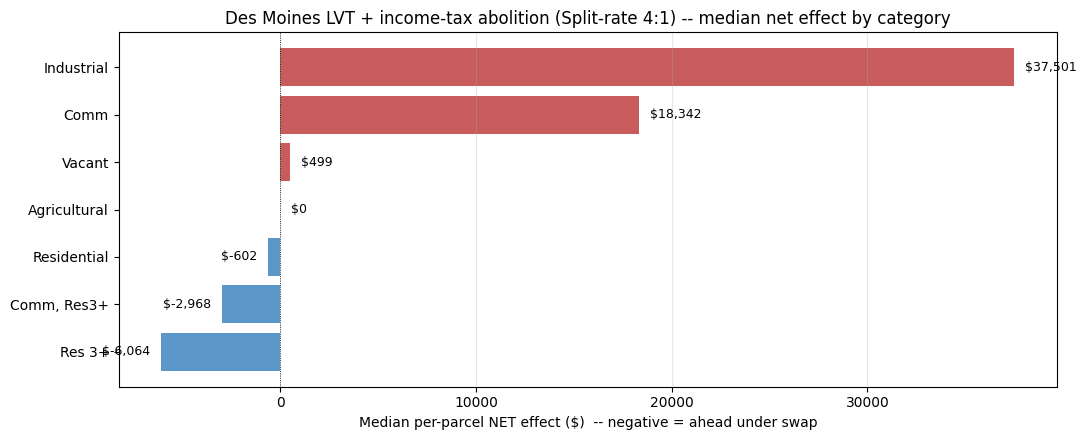

In [34]:
if swap_ready:
    # Chart A (swap): median NET per-parcel effect ($) by category.
    # Negative = parcel comes out ahead under the swap.
    plot_data = swap_cat[swap_cat["property_count"] > 50].copy()
    plot_data = plot_data.sort_values("median_net_change", ascending=True)

    fig, ax = plt.subplots(figsize=(11, max(4.5, len(plot_data) * 0.55)))
    colors = ["#4d8ec4" if v < 0 else "#c44d4d" for v in plot_data["median_net_change"]]
    y = np.arange(len(plot_data))
    ax.barh(y, plot_data["median_net_change"], color=colors, alpha=0.92)
    ax.axvline(0, color="black", linewidth=0.6, linestyle="dotted")
    ax.set_yticks(y)
    ax.set_yticklabels(plot_data["chart_category"])
    ax.set_xlabel("Median per-parcel NET effect ($)  -- negative = ahead under swap")
    ax.set_title(f"Des Moines LVT + income-tax abolition ({primary['label']}) -- median net effect by category")
    for idx, (_, row) in enumerate(plot_data.iterrows()):
        val = row["median_net_change"]
        ax.text(
            val + (max(plot_data['median_net_change'].abs()) * 0.015 * (1 if val >= 0 else -1)),
            idx,
            f"${val:,.0f}",
            va="center",
            ha="left" if val >= 0 else "right",
            fontsize=9,
        )
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


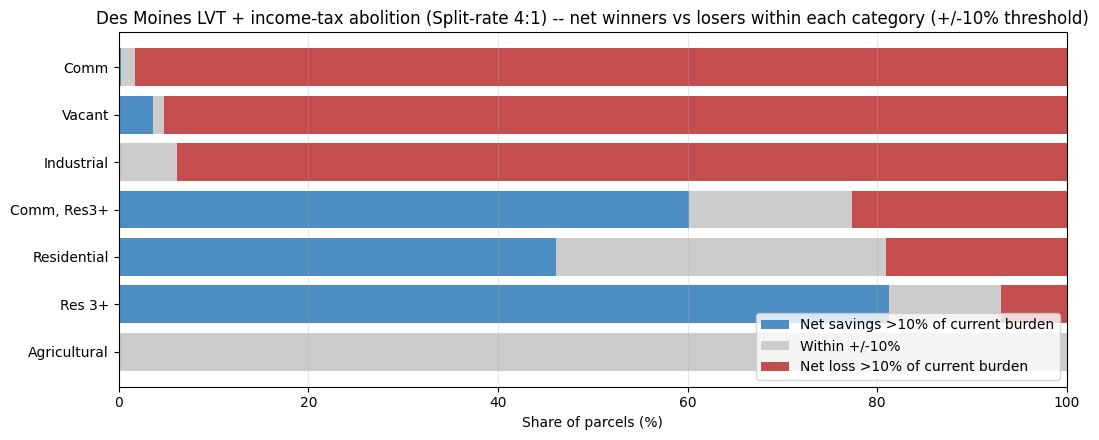

In [35]:
if swap_ready:
    # Chart B (swap): share of NET winners vs losers within each category,
    # using a +/-10% threshold against each parcel's CURRENT total burden
    # (property tax + currently-allocated income-tax burden). Matches the
    # pure-LVT chart's threshold semantics.
    plot_data = swap_cat[swap_cat["property_count"] > 50].copy()
    plot_data = plot_data.sort_values("pct_net_losers_gt10", ascending=True)

    fig, ax = plt.subplots(figsize=(11, max(4.5, len(plot_data) * 0.55)))
    y = np.arange(len(plot_data))
    ax.barh(y, plot_data["pct_net_winners_gt10"], color="#4d8ec4",
            label="Net savings >10% of current burden")
    ax.barh(y, plot_data["pct_within_10"], left=plot_data["pct_net_winners_gt10"],
            color="#cccccc", label="Within +/-10%")
    ax.barh(y, plot_data["pct_net_losers_gt10"],
            left=plot_data["pct_net_winners_gt10"] + plot_data["pct_within_10"],
            color="#c44d4d", label="Net loss >10% of current burden")
    ax.set_yticks(y)
    ax.set_yticklabels(plot_data["chart_category"])
    ax.set_xlabel("Share of parcels (%)")
    ax.set_xlim(0, 100)
    ax.set_title(f"Des Moines LVT + income-tax abolition ({primary['label']}) -- net winners vs losers within each category (+/-10% threshold)")
    ax.legend(loc="lower right")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


=== Swap quintile summary (income quintile) ===
                        n  median_property_tax_change  median_income_tax_savings  median_net_change
q                                                                                                  
Q1 (lowest income)   9038                 2651.884855                2595.386194         -28.507855
Q2                   8977                 2712.633960                2778.617692        -146.255690
Q3                   9094                 2955.040360                3827.298177        -957.390670
Q4                   8673                 3462.996005                3705.819243        -158.050857
Q5 (highest income)  8906                 4933.199980                6633.795550       -1355.710086


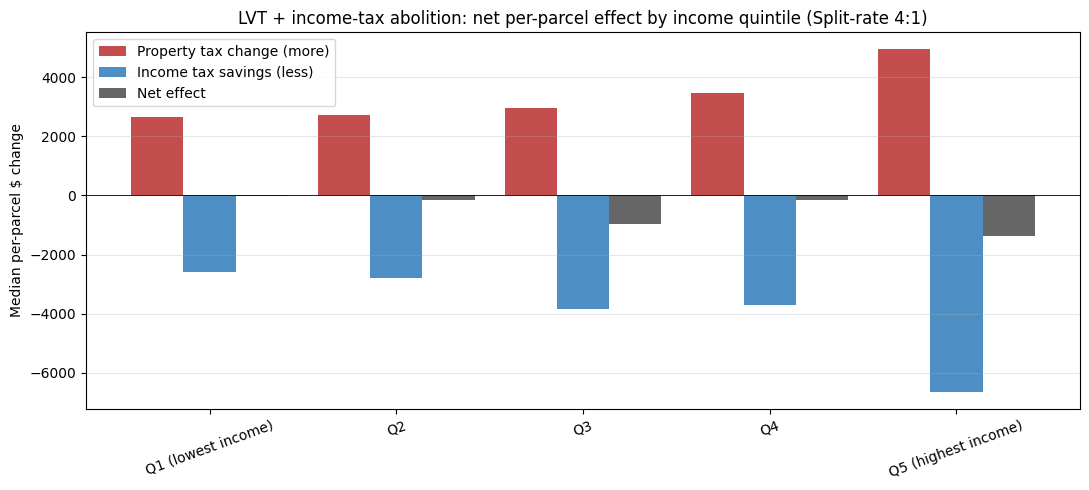

In [36]:
def _swap_quintile_chart(swap_result_nonexempt, swap_df, quintile_field, quintile_labels, title_suffix):
    """Build the swap equity quintile chart for either income or wealth."""
    merged = swap_result_nonexempt.merge(
        swap_df[["parcel_id", quintile_field]], on="parcel_id", how="left"
    )
    merged = merged.loc[merged[quintile_field].notna() & (merged[quintile_field] > 0)].copy()
    merged["q"] = pd.qcut(merged[quintile_field], q=5, labels=quintile_labels)
    q_summary = (
        merged.groupby("q", observed=True)
        .agg(
            n=("parcel_id", "size"),
            median_property_tax_change=("property_tax_change_under_swap", "median"),
            median_income_tax_savings=("parcel_income_tax_burden", "median"),
            median_net_change=("swap_net_change", "median"),
        )
    )
    print(f"=== Swap quintile summary ({title_suffix}) ===")
    print(q_summary.to_string())

    fig, ax = plt.subplots(figsize=(11, 5))
    width = 0.28
    x = np.arange(len(q_summary))
    ax.bar(x - width, q_summary["median_property_tax_change"], width, label="Property tax change (more)", color="#c44d4d")
    ax.bar(x,         -q_summary["median_income_tax_savings"], width, label="Income tax savings (less)", color="#4d8ec4")
    ax.bar(x + width,  q_summary["median_net_change"], width, label="Net effect", color="#666666")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(q_summary.index, rotation=20)
    ax.set_ylabel("Median per-parcel $ change")
    ax.set_title(f"LVT + income-tax abolition: net per-parcel effect by {title_suffix} ({primary['label']})")
    ax.legend(loc="best")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    return q_summary


if swap_ready:
    _swap_quintile_chart(
        swap_result_nonexempt, swap_df,
        quintile_field="median_income",
        quintile_labels=["Q1 (lowest income)", "Q2", "Q3", "Q4", "Q5 (highest income)"],
        title_suffix="income quintile",
    )


### Same swap picture by wealth quintile (BG median home value)

=== Swap quintile summary (wealth quintile) ===
                        n  median_property_tax_change  median_income_tax_savings  median_net_change
q                                                                                                  
Q1 (lowest wealth)   9186                 2356.733214                2416.740228        -109.443386
Q2                   9254                 2737.255540                3115.427472        -304.500561
Q3                   8784                 3361.063096                3351.985380        -243.723436
Q4                   9330                 3948.117162                4332.239686        -330.125760
Q5 (highest wealth)  8772                 5225.940667                7242.165060       -1570.333026


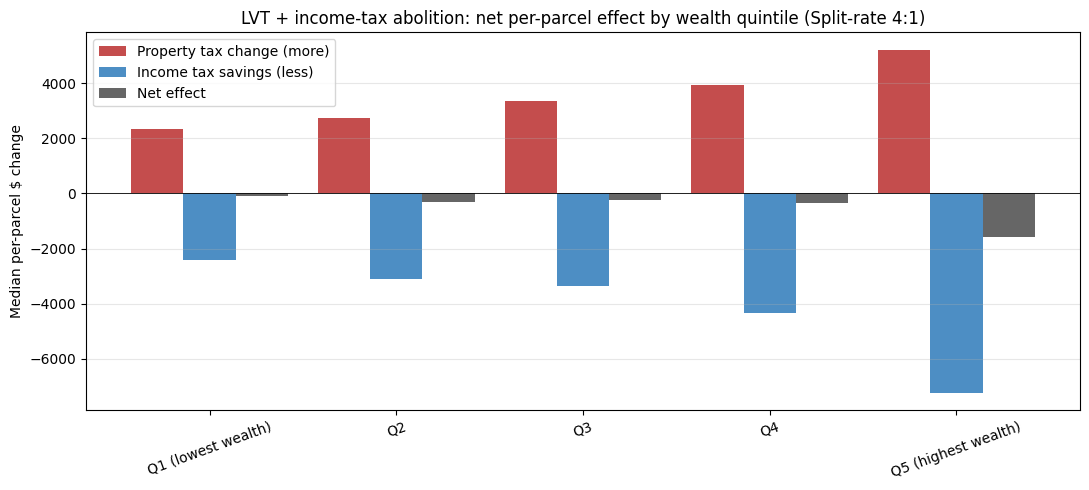

In [37]:
if swap_ready and "median_home_value" in swap_df.columns:
    _swap_quintile_chart(
        swap_result_nonexempt, swap_df,
        quintile_field="median_home_value",
        quintile_labels=["Q1 (lowest wealth)", "Q2", "Q3", "Q4", "Q5 (highest wealth)"],
        title_suffix="wealth quintile",
    )


### Same swap picture by renter quintile

Caveat: per-parcel chart shows landlord-side burden shift. Renters' direct
benefit shows up as the dividend in §15.

=== Swap quintile summary (renter quintile) ===
                           n  median_property_tax_change  median_income_tax_savings  median_net_change
q                                                                                                     
Q1 (low renter share)   9008                 3537.606940                3836.814026        -216.280003
Q2                      8760                 3320.356439                3899.913059        -358.928369
Q3                      8783                 2790.479399                3327.013421        -478.736630
Q4                      8805                 3027.379280                3748.455598        -641.961810
Q5 (high renter share)  8728                 3126.610954                3465.887852        -446.460148


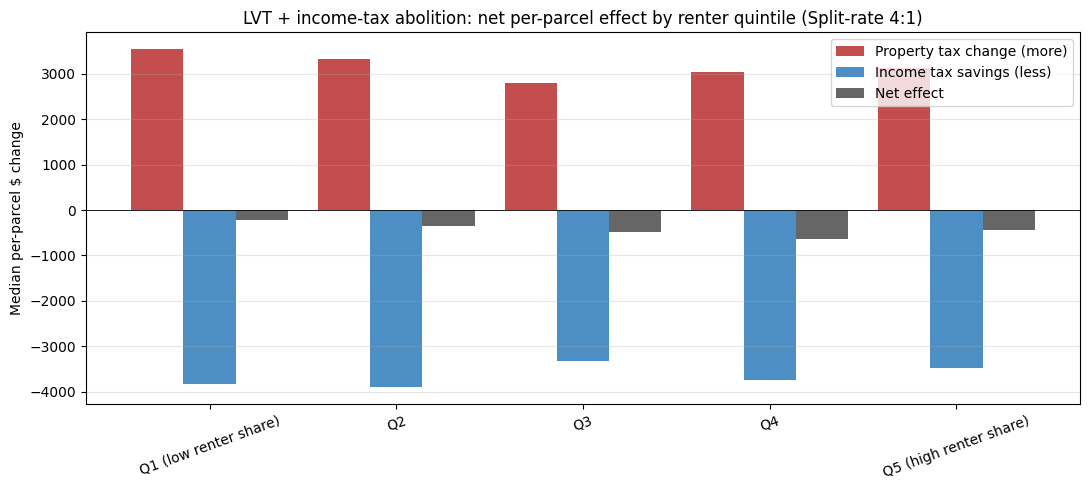

In [38]:
if swap_ready and "renter_share" in swap_df.columns:
    _swap_quintile_chart(
        swap_result_nonexempt, swap_df,
        quintile_field="renter_share",
        quintile_labels=["Q1 (low renter share)", "Q2", "Q3", "Q4", "Q5 (high renter share)"],
        title_suffix="renter quintile",
    )


## 15. Citizens dividend layer

A third layer on top of the swap: **per-capita citizens dividend**, the
classic Georgist redistribution. Every DM resident receives a flat $X/year;
the additional revenue need is added to the property-tax target and the
land millage floats up to fund it.

### Mechanics

1. Citizens dividend per resident per year: **`DIVIDEND_PER_CAPITA`** (configurable below; default $1,000).
2. Estimate population on each parcel: allocate each block group's ACS total
   population (B01003) to its residential + agricultural parcels weighted by
   full market value. Non-household parcels receive zero residents.
3. Total dividend payout = `DIVIDEND_PER_CAPITA × sum(parcel_residents)`. By
   construction this ≈ `DIVIDEND_PER_CAPITA × DM_population`.
4. New revenue target = swap target (current property tax + allocated income
   tax) + total dividend payout.
5. Re-run the same four scenarios at this larger target.
6. For each parcel: **net effect** = (new property tax) − (current property tax)
   − (parcel income-tax burden) − (parcel dividend received).
   Negative = household nets out ahead under the full LVT + swap + dividend
   policy stack.

### Caveats

- ACS B01003 is total population including children. If you want adult-only
  per-capita dividends, replace with B01001 age-summed subset.
- Allocation by parcel market value within block group is a proxy; reality
  has more apartment units in lower-value parcels per dollar than single-
  family. Refinement: use B11001 household count + assumed parcel composition.
- Commercial / industrial parcels receive zero dividend (no residents). Their
  income-tax savings (corporate side) still apply from the swap layer.

In [39]:
DIVIDEND_PER_CAPITA = 1000.0  # $ per resident per year; tweak to sweep
print(f"Citizens dividend rate: ${DIVIDEND_PER_CAPITA:,.0f} per resident per year")


Citizens dividend rate: $1,000 per resident per year


In [40]:
if swap_ready:
    # Allocate ACS block-group population (B01003) to residential + agricultural
    # parcels, weighted by full market value (consistent with the personal-
    # income-tax allocation in the swap section). policy_analysis.
    # allocate_bg_total_by_weight conserves each BG's total within its own
    # rows — exactly what we want for population.
    household_buckets = {"residential", "agricultural"}
    is_household = swap_df["rollback_bucket"].isin(household_buckets)
    swap_df["parcel_residents"] = policy_analysis.allocate_bg_total_by_weight(
        swap_df,
        bg_col="std_geoid",
        bg_total_col="bg_total_pop",
        weight_col="full_market_value",
        target_mask=is_household,
    )
    swap_df["parcel_dividend"] = DIVIDEND_PER_CAPITA * swap_df["parcel_residents"]

    total_dm_population = swap_df.drop_duplicates(subset=["std_geoid"])["bg_total_pop"].sum()
    total_residents_allocated = swap_df["parcel_residents"].sum()
    total_dividend_cost = swap_df["parcel_dividend"].sum()

    print(f"DM total population (sum of matched BGs):       {total_dm_population:>12,.0f}")
    print(f"Population allocated to household parcels:      {total_residents_allocated:>12,.0f}")
    print(f"  (gap = pop in BGs with no household parcels)")
    print(f"Total citizens dividend payout @ ${DIVIDEND_PER_CAPITA:,.0f}/cap: ${total_dividend_cost:>15,.0f}")


DM total population (sum of matched BGs):            222,197
Population allocated to household parcels:           219,677
  (gap = pop in BGs with no household parcels)
Total citizens dividend payout @ $1,000/cap: $    219,677,000


In [41]:
if swap_ready:
    # New revenue target = swap target + total dividend payout.
    dividend_target_revenue = swap_target_revenue + total_dividend_cost
    print(f"Swap target revenue (without dividend):     ${swap_target_revenue:>15,.0f}")
    print(f"Dividend payout (additional revenue need):  ${total_dividend_cost:>15,.0f}")
    print(f"New target including dividend:              ${dividend_target_revenue:>15,.0f}")
    print(f"Multiplier vs current property tax:         {dividend_target_revenue / total_revenue:.3f}x")

    # Re-run the scenarios at the augmented target. Carry parcel_dividend through
    # so the per-parcel net effect calc below can use it.
    dividend_input = gdf[[
        "parcel_id", "taxable_land_value", "taxable_improvement_value", "exemption_flag",
        "PROPERTY_CATEGORY", "property_land_use_category", "chart_category", "current_tax",
    ]].merge(
        swap_df[["parcel_id", "parcel_income_tax_burden", "parcel_residents", "parcel_dividend"]],
        on="parcel_id", how="left",
    )
    dividend_input["parcel_income_tax_burden"] = dividend_input["parcel_income_tax_burden"].fillna(0.0)
    dividend_input["parcel_dividend"] = dividend_input["parcel_dividend"].fillna(0.0)

    scenarios_dividend = run_scenarios(dividend_input, dividend_target_revenue)

    print()
    print(f"{'Scenario':<35}{'Land mills (pure)':>20}{'Land mills (swap)':>20}{'Land mills (+ div)':>20}")
    print("-" * 95)
    for key in scenarios_all:
        a = scenarios_all[key]["land_millage"]
        b = scenarios_swap[key]["land_millage"]
        c = scenarios_dividend[key]["land_millage"]
        print(f"{scenarios_all[key]['label']:<35}{a:>20.4f}{b:>20.4f}{c:>20.4f}")


Swap target revenue (without dividend):     $    675,381,174
Dividend payout (additional revenue need):  $    219,677,000
New target including dividend:              $    895,058,174
Multiplier vs current property tax:         2.442x
Building abatement model (100.0% abatement)
Millage rate: 512.3373
Total tax revenue: $894,657,583.89
Target revenue: $894,657,583.89
Revenue difference: $-0.00 (-0.0000%)

Scenario                              Land mills (pure)   Land mills (swap)  Land mills (+ div)
-----------------------------------------------------------------------------------------------
Split-rate 2:1                                  70.8759            130.6441            173.1630
Split-rate 4:1                                 105.9441            195.2846            258.8413
Split-rate 8:1                                 140.7692            259.4771            343.9256
Full building abatement (100%)                 209.7003            386.5364            512.3373


In [42]:
if swap_ready:
    # Per-parcel net effect under primary scenario at dividend target.
    primary_dividend = scenarios_dividend[primary_key]
    div_result = primary_dividend["df"].merge(
        gdf[["parcel_id", "current_tax"]].rename(columns={"current_tax": "current_property_tax"}),
        on="parcel_id", how="left",
    )
    div_result["parcel_income_tax_burden"] = div_result["parcel_income_tax_burden"].fillna(0.0)
    div_result["parcel_dividend"] = div_result["parcel_dividend"].fillna(0.0)
    div_result["new_property_tax_under_dividend"] = div_result["new_tax"]
    div_result["property_tax_change_under_dividend"] = (
        div_result["new_property_tax_under_dividend"] - div_result["current_property_tax"]
    )
    # Net = property tax up - income tax saved - dividend received.
    # Negative = household / business comes out ahead under LVT + swap + dividend.
    div_result["dividend_net_change"] = (
        div_result["property_tax_change_under_dividend"]
        - div_result["parcel_income_tax_burden"]
        - div_result["parcel_dividend"]
    )
    # Net change as % of CURRENT total burden (= current property tax + income tax).
    div_result["dividend_baseline"] = (
        div_result["current_property_tax"] + div_result["parcel_income_tax_burden"]
    )
    div_result["dividend_net_change_pct"] = np.where(
        div_result["dividend_baseline"] > 0,
        100.0 * div_result["dividend_net_change"] / div_result["dividend_baseline"],
        np.nan,
    )

    div_result_nonexempt = div_result.loc[div_result["exemption_flag"] == 0].copy()
    print(f"Per-parcel net effect of LVT + swap + ${int(DIVIDEND_PER_CAPITA):,}/cap dividend ({primary_dividend['label']}):")
    print(div_result_nonexempt["dividend_net_change"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_string())
    print()
    print(f"Parcels coming out AHEAD with dividend: {(div_result_nonexempt['dividend_net_change'] < 0).sum():,}"
          f" ({(div_result_nonexempt['dividend_net_change'] < 0).mean()*100:.1f}%)")
    print(f"Parcels paying MORE with dividend:      {(div_result_nonexempt['dividend_net_change'] > 0).sum():,}"
          f" ({(div_result_nonexempt['dividend_net_change'] > 0).mean()*100:.1f}%)")


Per-parcel net effect of LVT + swap + $1,000/cap dividend (Split-rate 4:1):
count    4.610000e+04
mean     9.495046e-13
std      6.004996e+04
min     -5.687349e+06
5%      -1.370223e+04
25%     -4.502447e+03
50%     -1.288988e+03
75%      5.767982e+02
95%      5.168448e+03
max      2.521052e+06

Parcels coming out AHEAD with dividend: 30,963 (67.2%)
Parcels paying MORE with dividend:      15,097 (32.7%)


In [43]:
if swap_ready:
    # Per-category dividend-layer summary.
    div_cat = (
        div_result_nonexempt
        .groupby("chart_category", observed=True)
        .agg(
            property_count=("parcel_id", "size"),
            median_dividend_received=("parcel_dividend", "median"),
            median_property_tax_change=("property_tax_change_under_dividend", "median"),
            median_income_tax_savings=("parcel_income_tax_burden", "median"),
            median_net_change=("dividend_net_change", "median"),
            median_net_change_pct=("dividend_net_change_pct", "median"),
            pct_net_winners_gt10=("dividend_net_change_pct", lambda s: (s < -10).mean() * 100),
            pct_net_losers_gt10=("dividend_net_change_pct", lambda s: (s > 10).mean() * 100),
        )
        .reset_index()
    )
    div_cat["pct_within_10"] = (
        100.0 - div_cat["pct_net_winners_gt10"] - div_cat["pct_net_losers_gt10"]
    )
    div_cat


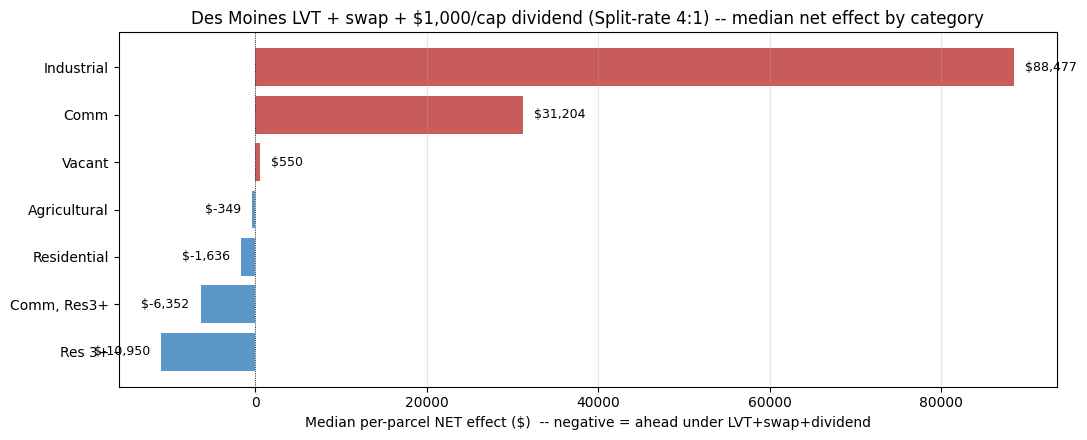

In [44]:
if swap_ready:
    # Chart A (dividend): median NET per-parcel effect ($) by category.
    plot_data = div_cat[div_cat["property_count"] > 50].copy()
    plot_data = plot_data.sort_values("median_net_change", ascending=True)

    fig, ax = plt.subplots(figsize=(11, max(4.5, len(plot_data) * 0.55)))
    colors = ["#4d8ec4" if v < 0 else "#c44d4d" for v in plot_data["median_net_change"]]
    y = np.arange(len(plot_data))
    ax.barh(y, plot_data["median_net_change"], color=colors, alpha=0.92)
    ax.axvline(0, color="black", linewidth=0.6, linestyle="dotted")
    ax.set_yticks(y)
    ax.set_yticklabels(plot_data["chart_category"])
    ax.set_xlabel("Median per-parcel NET effect ($)  -- negative = ahead under LVT+swap+dividend")
    ax.set_title(
        f"Des Moines LVT + swap + ${int(DIVIDEND_PER_CAPITA):,}/cap dividend ({primary_dividend['label']}) "
        f"-- median net effect by category"
    )
    for idx, (_, row) in enumerate(plot_data.iterrows()):
        val = row["median_net_change"]
        ax.text(
            val + (max(plot_data['median_net_change'].abs()) * 0.015 * (1 if val >= 0 else -1)),
            idx,
            f"${val:,.0f}",
            va="center",
            ha="left" if val >= 0 else "right",
            fontsize=9,
        )
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


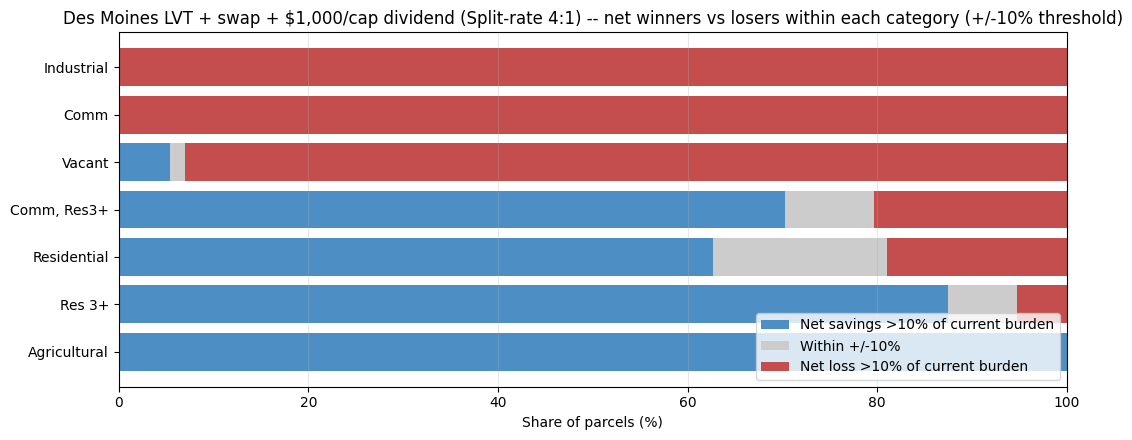

In [45]:
if swap_ready:
    # Chart B (dividend): share of NET winners vs losers within each category,
    # +/-10% threshold against current total burden.
    plot_data = div_cat[div_cat["property_count"] > 50].copy()
    plot_data = plot_data.sort_values("pct_net_losers_gt10", ascending=True)

    fig, ax = plt.subplots(figsize=(11, max(4.5, len(plot_data) * 0.55)))
    y = np.arange(len(plot_data))
    ax.barh(y, plot_data["pct_net_winners_gt10"], color="#4d8ec4",
            label="Net savings >10% of current burden")
    ax.barh(y, plot_data["pct_within_10"], left=plot_data["pct_net_winners_gt10"],
            color="#cccccc", label="Within +/-10%")
    ax.barh(y, plot_data["pct_net_losers_gt10"],
            left=plot_data["pct_net_winners_gt10"] + plot_data["pct_within_10"],
            color="#c44d4d", label="Net loss >10% of current burden")
    ax.set_yticks(y)
    ax.set_yticklabels(plot_data["chart_category"])
    ax.set_xlabel("Share of parcels (%)")
    ax.set_xlim(0, 100)
    ax.set_title(
        f"Des Moines LVT + swap + ${int(DIVIDEND_PER_CAPITA):,}/cap dividend ({primary_dividend['label']}) "
        f"-- net winners vs losers within each category (+/-10% threshold)"
    )
    ax.legend(loc="lower right")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


### Dividend layer — progressivity by income and wealth

The same equity question applied to the LVT + swap + dividend stack. Bars
show (property tax up) vs (income tax saved) vs (dividend received) vs
(net effect) per quintile.

=== Dividend quintile summary (income quintile) ===
                        n  median_property_tax_change  median_income_tax_savings  median_dividend_received  median_net_change
q                                                                                                                            
Q1 (lowest income)   9038                 4639.964341                2595.386194               2891.490770        -905.742270
Q2                   8977                 4774.081881                2778.617692               3146.403068       -1267.514616
Q3                   9094                 5202.385584                3827.298177               3621.191624       -2455.234150
Q4                   8673                 5966.336844                3705.819243               3078.595879        -683.195167
Q5 (highest income)  8906                 8453.878801                6633.795550               3868.753476       -1280.537842


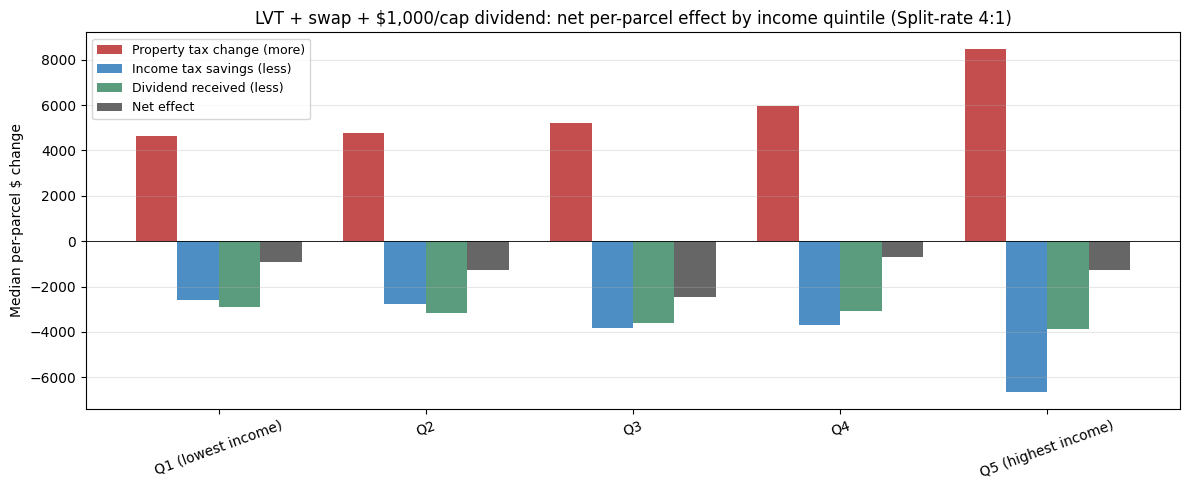

In [46]:
def _dividend_quintile_chart(div_result_nonexempt, swap_df, quintile_field, quintile_labels, title_suffix):
    """Build the dividend equity quintile chart for either income or wealth."""
    merged = div_result_nonexempt.merge(
        swap_df[["parcel_id", quintile_field]], on="parcel_id", how="left"
    )
    merged = merged.loc[merged[quintile_field].notna() & (merged[quintile_field] > 0)].copy()
    merged["q"] = pd.qcut(merged[quintile_field], q=5, labels=quintile_labels)
    q_summary = (
        merged.groupby("q", observed=True)
        .agg(
            n=("parcel_id", "size"),
            median_property_tax_change=("property_tax_change_under_dividend", "median"),
            median_income_tax_savings=("parcel_income_tax_burden", "median"),
            median_dividend_received=("parcel_dividend", "median"),
            median_net_change=("dividend_net_change", "median"),
        )
    )
    print(f"=== Dividend quintile summary ({title_suffix}) ===")
    print(q_summary.to_string())

    fig, ax = plt.subplots(figsize=(12, 5))
    width = 0.20
    x = np.arange(len(q_summary))
    ax.bar(x - 1.5*width, q_summary["median_property_tax_change"], width, label="Property tax change (more)", color="#c44d4d")
    ax.bar(x - 0.5*width, -q_summary["median_income_tax_savings"], width, label="Income tax savings (less)", color="#4d8ec4")
    ax.bar(x + 0.5*width, -q_summary["median_dividend_received"], width, label="Dividend received (less)", color="#5b9c7e")
    ax.bar(x + 1.5*width,  q_summary["median_net_change"], width, label="Net effect", color="#666666")
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(q_summary.index, rotation=20)
    ax.set_ylabel("Median per-parcel $ change")
    ax.set_title(
        f"LVT + swap + ${int(DIVIDEND_PER_CAPITA):,}/cap dividend: net per-parcel effect "
        f"by {title_suffix} ({primary_dividend['label']})"
    )
    ax.legend(loc="best", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
    return q_summary


if swap_ready:
    _dividend_quintile_chart(
        div_result_nonexempt, swap_df,
        quintile_field="median_income",
        quintile_labels=["Q1 (lowest income)", "Q2", "Q3", "Q4", "Q5 (highest income)"],
        title_suffix="income quintile",
    )


=== Dividend quintile summary (wealth quintile) ===
                        n  median_property_tax_change  median_income_tax_savings  median_dividend_received  median_net_change
q                                                                                                                            
Q1 (lowest wealth)   9186                 4045.347111                2416.740228               2874.848453       -1253.532424
Q2                   9254                 4798.880173                3115.427472               3149.584880       -1380.440519
Q3                   8784                 5772.093347                3351.985380               2908.988982        -837.398985
Q4                   9330                 6694.534609                4332.239686               3666.407598       -1006.684472
Q5 (highest wealth)  8772                 8941.276002                7242.165060               4155.415843       -1852.180854


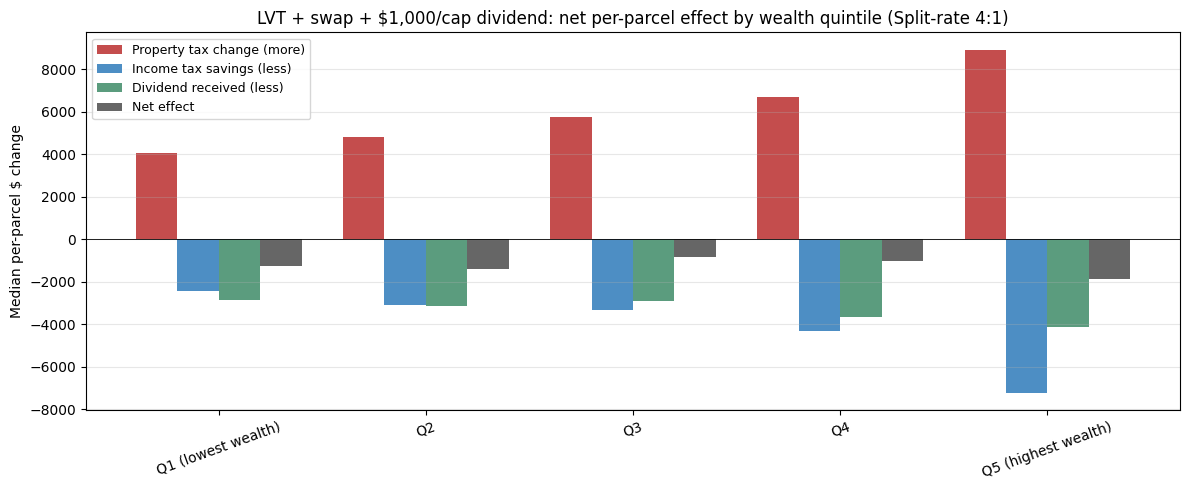

In [47]:
if swap_ready and "median_home_value" in swap_df.columns:
    _dividend_quintile_chart(
        div_result_nonexempt, swap_df,
        quintile_field="median_home_value",
        quintile_labels=["Q1 (lowest wealth)", "Q2", "Q3", "Q4", "Q5 (highest wealth)"],
        title_suffix="wealth quintile",
    )


=== Dividend quintile summary (renter quintile) ===
                           n  median_property_tax_change  median_income_tax_savings  median_dividend_received  median_net_change
q                                                                                                                               
Q1 (low renter share)   9008                 6063.887730                3836.814026               3270.379169       -1054.273246
Q2                      8760                 5727.358643                3899.913059               3457.248491       -1153.836301
Q3                      8783                 4936.566216                3327.013421               3404.878422       -1801.387333
Q4                      8805                 5275.752196                3748.455598               3088.062964       -1266.409826
Q5 (high renter share)  8728                 5496.049402                3465.887852               3763.061145       -1677.585996


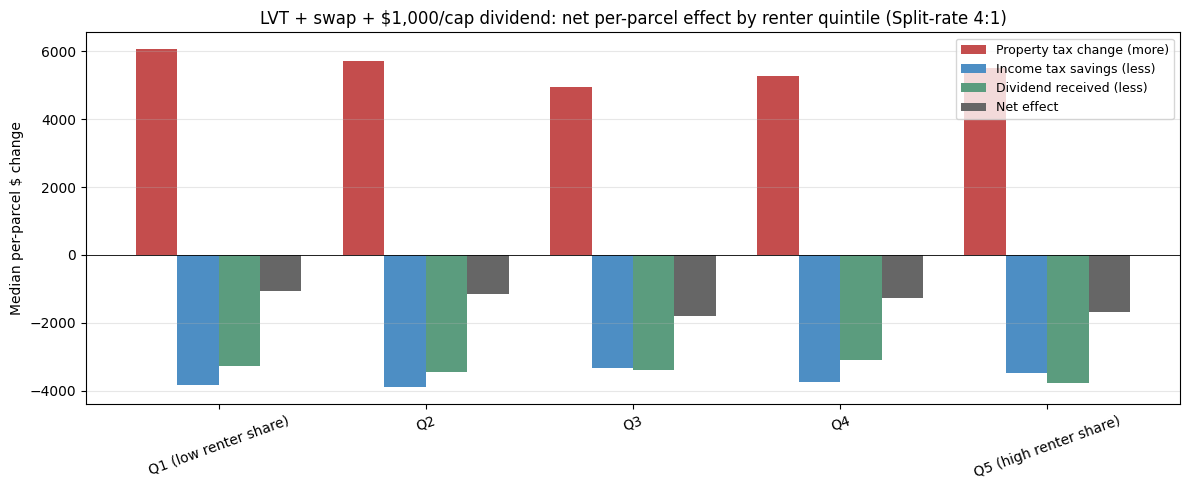

In [48]:
if swap_ready and "renter_share" in swap_df.columns:
    _dividend_quintile_chart(
        div_result_nonexempt, swap_df,
        quintile_field="renter_share",
        quintile_labels=["Q1 (low renter share)", "Q2", "Q3", "Q4", "Q5 (high renter share)"],
        title_suffix="renter quintile",
    )


## 16. Land-share breakdown within categories

Three questions answered together:

1. For any given category, what % of parcels win vs lose? (already in §15)
2. For any given category, does the median parcel win or lose, and by how much? (already in §15)
3. **Within each category, how does win/lose distribute across land-share buckets?**
   I.e., does an improvement-heavy Residential parcel (mostly building, little land)
   behave the same as a land-heavy Residential parcel (mostly land, small building)?

This section computes `land_share = land_value / (land_value + improvement_value)`
for each non-exempt parcel, buckets parcels into five 20%-wide bins, and shows the
distribution of winners / neutral / losers within each bucket for each Polk class.

The headline expectation: improvement-heavy parcels (low land share) should be
winners, land-heavy parcels (high land share) should be losers, regardless of
category — that's the whole point of an LVT shift. This section shows whether
that holds and how cleanly.

Applied to the most comprehensive scenario: **LVT + state income tax abolition
+ $1,000/cap citizens dividend, primary 4:1 split-rate, ag carved out**.

In [49]:
if swap_ready:
    # Pull land/improvement values from gdf and compute land share + bucket.
    ls = div_result_nonexempt.merge(
        gdf[["parcel_id", "land_value", "improvement_value"]],
        on="parcel_id", how="left",
    )
    _denom = (ls["land_value"].fillna(0) + ls["improvement_value"].fillna(0))
    ls["land_share_pct"] = np.where(
        _denom > 0,
        100.0 * ls["land_value"].fillna(0) / _denom,
        np.nan,
    )
    ls["land_share_bucket"] = pd.cut(
        ls["land_share_pct"],
        bins=[-0.01, 20, 40, 60, 80, 100.01],
        labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"],
    )
    ls["is_winner_gt10"] = ls["dividend_net_change_pct"] < -10
    ls["is_loser_gt10"]  = ls["dividend_net_change_pct"] > 10

    print("Land-share bucket distribution (non-exempt parcels):")
    print(ls["land_share_bucket"].value_counts().sort_index().to_string())


Land-share bucket distribution (non-exempt parcels):
land_share_bucket
0-20%      25065
20-40%     17695
40-60%       848
60-80%       328
80-100%     2124


In [50]:
if swap_ready:
    ls_summary = (
        ls.groupby(["chart_category", "land_share_bucket"], observed=True)
        .agg(
            n=("parcel_id", "size"),
            median_net=("dividend_net_change", "median"),
            median_net_pct=("dividend_net_change_pct", "median"),
            pct_winners=("is_winner_gt10", lambda s: s.mean() * 100),
            pct_losers=("is_loser_gt10",  lambda s: s.mean() * 100),
        )
        .reset_index()
    )
    ls_summary["pct_within_10"] = 100.0 - ls_summary["pct_winners"] - ls_summary["pct_losers"]
    ls_summary


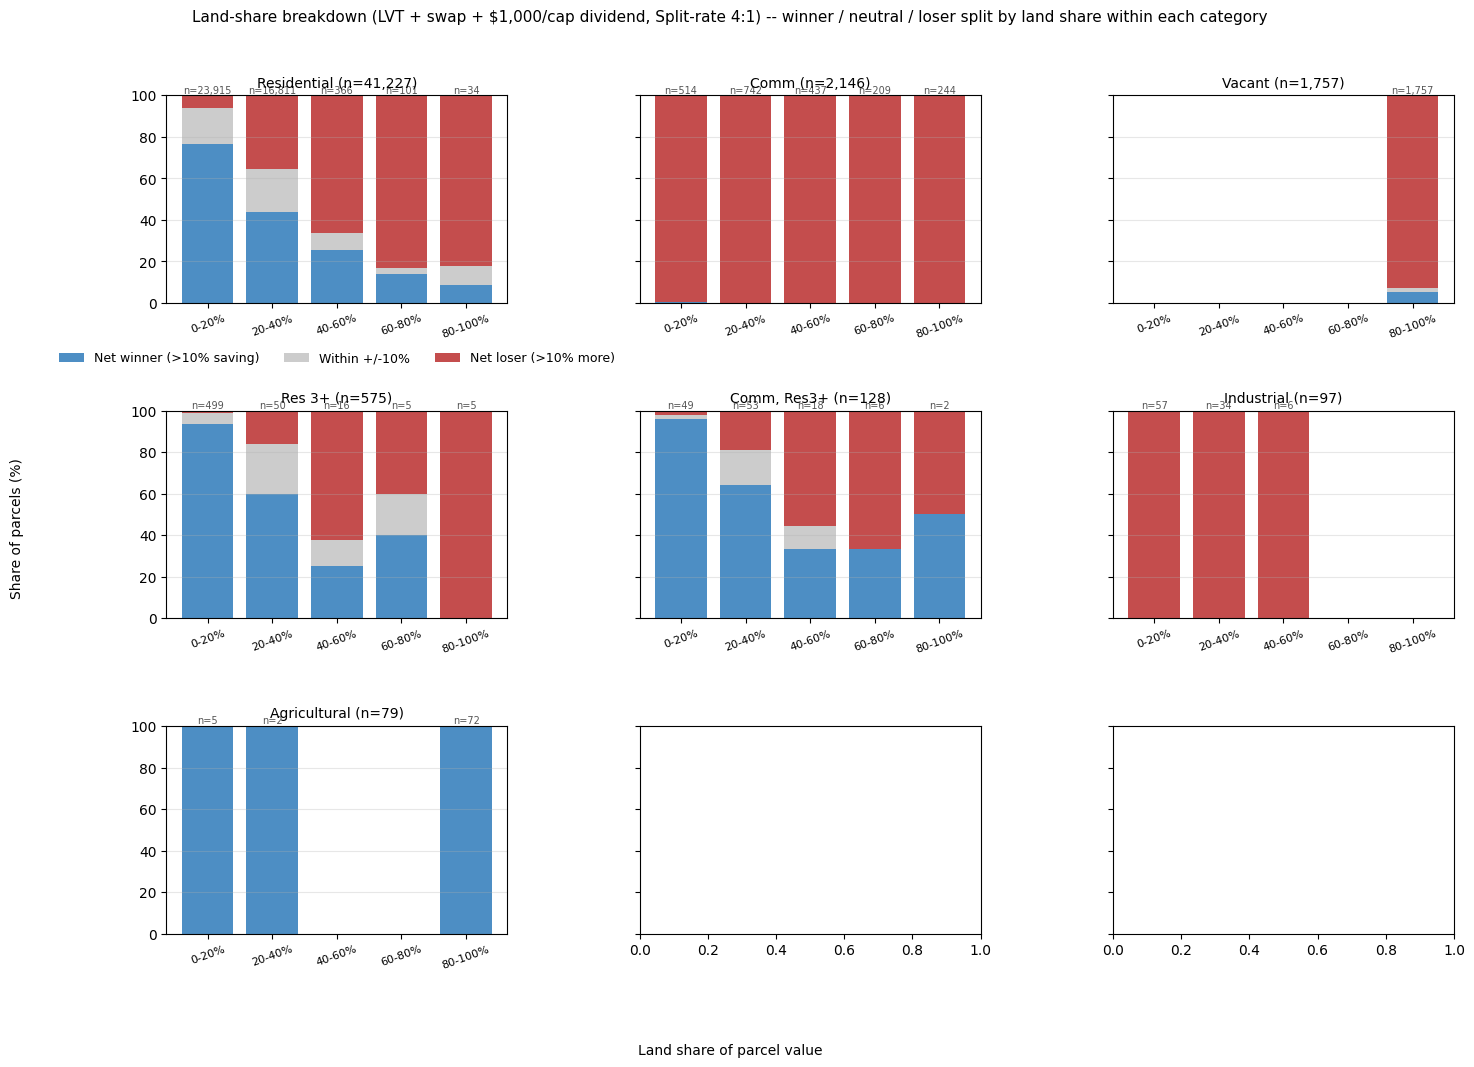

In [51]:
if swap_ready:
    # Small multiples: one panel per major category (>50 parcels).
    # Each panel: stacked bar per land-share bucket, showing win/neutral/lose split.
    cat_counts = ls.groupby("chart_category", observed=True).size().sort_values(ascending=False)
    major_cats = [c for c in cat_counts.index if cat_counts[c] > 50]

    n_cats = len(major_cats)
    n_cols = min(3, n_cats)
    n_rows = (n_cats + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.6 * n_rows), sharey=True)
    axes_flat = axes.flat if n_rows * n_cols > 1 else [axes]

    bucket_order = ["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"]
    for ax, cat in zip(axes_flat, major_cats):
        sub = ls_summary[ls_summary["chart_category"] == cat].set_index("land_share_bucket")
        sub = sub.reindex(bucket_order)
        x = np.arange(len(bucket_order))
        winners = sub["pct_winners"].fillna(0).values
        neutral = sub["pct_within_10"].fillna(0).values
        losers  = sub["pct_losers"].fillna(0).values
        n_parc  = sub["n"].fillna(0).astype(int).values
        ax.bar(x, winners, color="#4d8ec4", label="Net winner (>10% saving)")
        ax.bar(x, neutral, bottom=winners, color="#cccccc", label="Within +/-10%")
        ax.bar(x, losers, bottom=winners + neutral, color="#c44d4d", label="Net loser (>10% more)")
        ax.set_xticks(x)
        ax.set_xticklabels(bucket_order, rotation=20, fontsize=8)
        ax.set_title(f"{cat} (n={cat_counts[cat]:,})", fontsize=10)
        ax.set_ylim(0, 100)
        ax.grid(axis="y", alpha=0.3)
        # Annotate parcel count above each bar (small)
        for xi, n in zip(x, n_parc):
            if n > 0:
                ax.text(xi, 101, f"n={n:,}", ha="center", fontsize=7, color="#555555")
    for ax in list(axes_flat)[n_cats:]:
        ax.set_visible(False)

    # Shared legend on the first subplot
    axes_flat = list(fig.axes)
    axes_flat[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=9, frameon=False)
    fig.suptitle(
        f"Land-share breakdown (LVT + swap + ${int(DIVIDEND_PER_CAPITA):,}/cap dividend, "
        f"{primary_dividend['label']}) -- winner / neutral / loser split by land share within each category",
        fontsize=11,
    )
    fig.supxlabel("Land share of parcel value", fontsize=10)
    fig.supylabel("Share of parcels (%)", fontsize=10)
    plt.tight_layout(rect=[0.02, 0.05, 1, 0.96])
    plt.show()


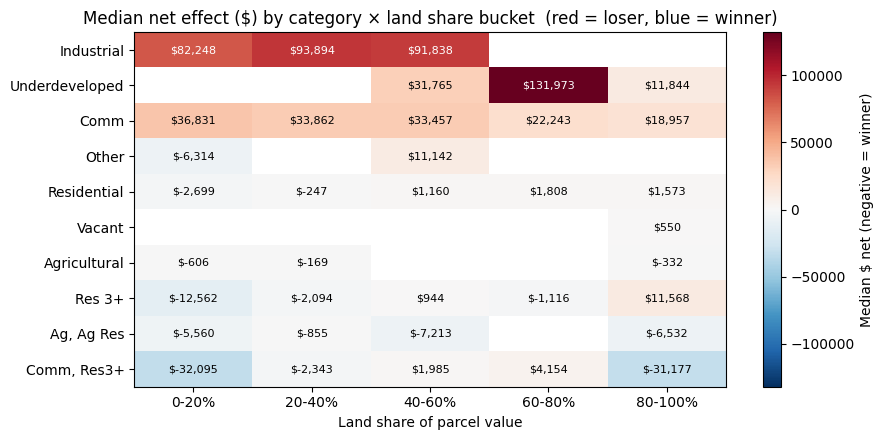

In [52]:
if swap_ready:
    # Heatmap-style table: median net change by category × land-share bucket.
    pivot = ls_summary.pivot(index="chart_category", columns="land_share_bucket", values="median_net")
    pivot = pivot.reindex(columns=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%"])
    # Sort categories by sum of medians (most-net-loser at top)
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(pivot))))
    vmax = max(abs(pivot.min().min()), abs(pivot.max().max()))
    im = ax.imshow(pivot.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Land share of parcel value")
    ax.set_title("Median net effect ($) by category × land share bucket  (red = loser, blue = winner)")
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.iat[i, j]
            if pd.notna(v):
                ax.text(j, i, f"${v:,.0f}", ha="center", va="center",
                        color="white" if abs(v) > vmax * 0.4 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, label="Median $ net (negative = winner)")
    plt.tight_layout()
    plt.show()


## 17. Validation + next steps

### Sanity checks performed in this notebook

- **Rate sourcing:** Iowa rollback and Polk consolidated levy are both pulled from named published documents (see Sources at the top). The sidecar provenance is recorded by `scripts/des_moines_district_overlay.py`.
- **Revenue neutrality:** each reform scenario's `new_revenue` matches the current `total_revenue` to within rounding (see §5).
- **TIF distortion:** §6 shows how excluding TIF-captured parcels changes the rate needed to hit the same target. Material but not enormous (~7.5% of taxable revenue).
- **Class-bucket coverage:** §3 prints rollback bucket distribution; any "exempt" classes are excluded from the solve.

### Known limitations

- **Agricultural rollback** uses a placeholder constant (0.8907). Tiny share of DM parcels but worth replacing with the precise AY 2024 county-specific value if any analysis hinges on it.
- **TIF mechanics** are simplified to "TIF-captured parcels contribute zero to the general fund." Real Iowa TIF math (frozen base value, increment captured, residual to general fund) is more granular — for parcels in long-established TIF districts where the increment dominates the base, this approximation is close; for newer TIF districts it overstates.
- **Credits** (homestead, military, family farm, business property tax credit replacement) are not modeled. They reduce final bills but don't affect the revenue-neutral solve on taxable values. Per Stage A of the modeling guide, post-tax credits are preserved unchanged by the reform.
- **No per-parcel actual-bill validation.** Polk's CGI form exposes per-parcel tax bills if scraped; comparing modeled current_tax to the published actual bill on a sample of ~500 parcels would tighten the rollback bucket mapping. Worth doing once before this notebook is used in any public-facing analysis.

### Reasonable next investigations

1. **Per-class scenarios** — model the reform with different rollback treatment (e.g., what if the reform also folded commercial/industrial back into a single tier?).
2. **Stacking with Iowa SF 718 (2023)** — model the impact of recent state-level levy caps interacting with a city-level LVT shift.
3. **Vacant land hotspots** — geographic concentration of the largest tax increases. Combine with the Civic Mapper parking layer (already published) to identify surface-lot redevelopment opportunities.
4. **Sensitivity to ratio choice** — how much does the median tax change for a typical single-family home shift between 2:1 and 8:1?
